# **Exploring Advanced Models for Real-time Bitcoin Price Prediction**

## **Importing The required libraries**

In [ ]:
import yfinance as yf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Let's get TensorFlow!
import tensorflow as tf

## **Check for GPU**

In order for our deep learning models to run as fast as possible, we'll need access to a GPU.
*   The GPU can be accessed by follwing these steps:
Runtime-> Change runtime -> GPU.




In [ ]:
# Check for GPU
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-7a5eef8f-c316-c22a-d82d-63a9d5b92fd5)


The Data is imported using **yfinance** library ticker function:
*   **yfinance** is a popular open source library developed by Ran Aroussi as a means to access the financial data available on Yahoo Finance.




In [ ]:
btc_ticker = yf.Ticker("BTC-USD")

The ticker object will download the price history of Bitcoin (BTC-USD).
Setting the period to max will give us everything from when yahoo finance started tracking bitcoin in 2014 through to the present.

In [ ]:
data = btc_ticker.history(period="max")
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0


In [ ]:
data.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-08-14 00:00:00+00:00,29283.263672,29660.253906,29124.105469,29408.443359,14013695304,0.0,0.0
2023-08-15 00:00:00+00:00,29408.048828,29439.121094,29088.853516,29170.347656,12640195779,0.0,0.0
2023-08-16 00:00:00+00:00,29169.074219,29221.976562,28701.779297,28701.779297,14949271904,0.0,0.0
2023-08-17 00:00:00+00:00,28699.802734,28745.947266,25409.111328,26664.550781,31120851211,0.0,0.0
2023-08-18 00:00:00+00:00,26643.093750,26798.667969,26195.880859,26424.283203,34452156416,0.0,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3258 entries, 2014-09-17 00:00:00+00:00 to 2023-08-18 00:00:00+00:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          3258 non-null   float64
 1   High          3258 non-null   float64
 2   Low           3258 non-null   float64
 3   Close         3258 non-null   float64
 4   Volume        3258 non-null   int64  
 5   Dividends     3258 non-null   float64
 6   Stock Splits  3258 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 203.6 KB


In [ ]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3258.000000,3258.000000,3258.000000,3258.000000,3.258000e+03,3258.0,3258.0
mean,13808.621087,14140.523086,13444.605156,13815.239539,1.653618e+10,0.0,0.0
std,16013.901694,16409.471005,15561.771405,16010.561613,1.941286e+10,0.0,0.0
min,176.897003,211.731003,171.509995,178.102997,5.914570e+06,0.0,0.0
25%,773.115753,778.054489,765.545486,774.066513,1.341375e+08,0.0,0.0
50%,7831.865723,8069.529541,7614.513672,7852.364990,1.050710e+10,0.0,0.0
75%,20830.073242,21361.059570,20410.546875,20854.418945,2.730070e+10,0.0,0.0
max,67549.734375,68789.625000,66382.062500,67566.828125,3.509679e+11,0.0,0.0


In [ ]:
data.shape

(3258, 7)

In [ ]:
data.isna().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

array([[<Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>,
        <Axes: title={'center': 'Low'}>],
       [<Axes: title={'center': 'Close'}>,
        <Axes: title={'center': 'Volume'}>,
        <Axes: title={'center': 'Dividends'}>],
       [<Axes: title={'center': 'Stock Splits'}>, <Axes: >, <Axes: >]],
      dtype=object)

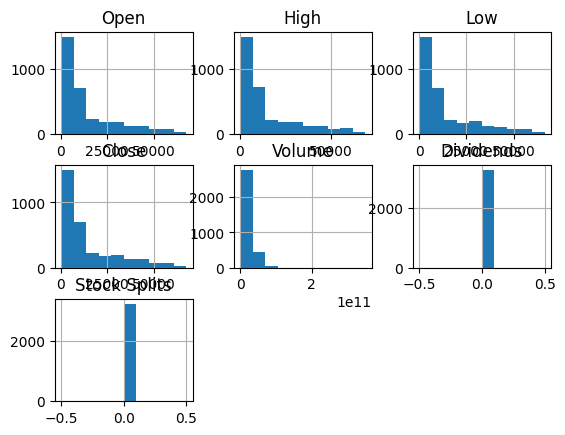

In [ ]:
data.hist()

## **Converting Index to Datetime format**

Since we use data from yfinance spanning almost 9 years and make predictions based on daily closing prices, we must convert the Index column to DateTime format.

In [ ]:
# Convert the index to datetime if it's not already
data.index = pd.to_datetime(data.index, format="%Y-%m-%d")

<Axes: xlabel='Date'>

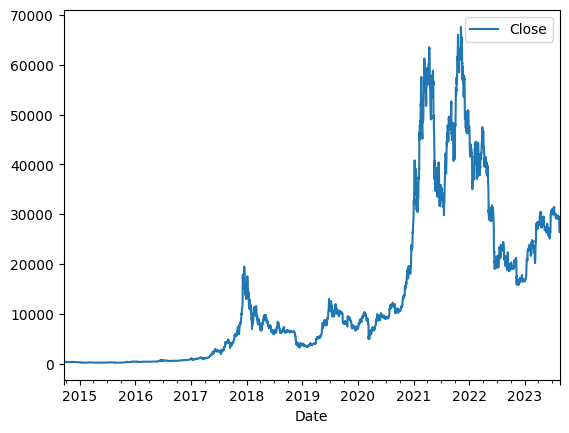

In [ ]:
data.plot.line(y="Close",use_index=True)

**Observation**:

*   The data from 17 September 2014 to 18 August 2023 is imported.
*   The investors who invested in Bitcoin until 2017 can now see a huge profit.
*   The investors who invested in Bitcoin after 2021 are experiencing financial loss at present as we can see the Bitcoing prices have been reduced a lot post 2022.

In [ ]:
# Select the Date and Close columns and rename "Close" to "Price"
bitcoin_price = data[['Close']].rename(columns={'Close': 'Price'})

# Now you can work with the "Date" and "Price" columns as needed
print(bitcoin_price.head())

                                Price
Date                                 
2014-09-17 00:00:00+00:00  457.334015
2014-09-18 00:00:00+00:00  424.440002
2014-09-19 00:00:00+00:00  394.795990
2014-09-20 00:00:00+00:00  408.903992
2014-09-21 00:00:00+00:00  398.821014


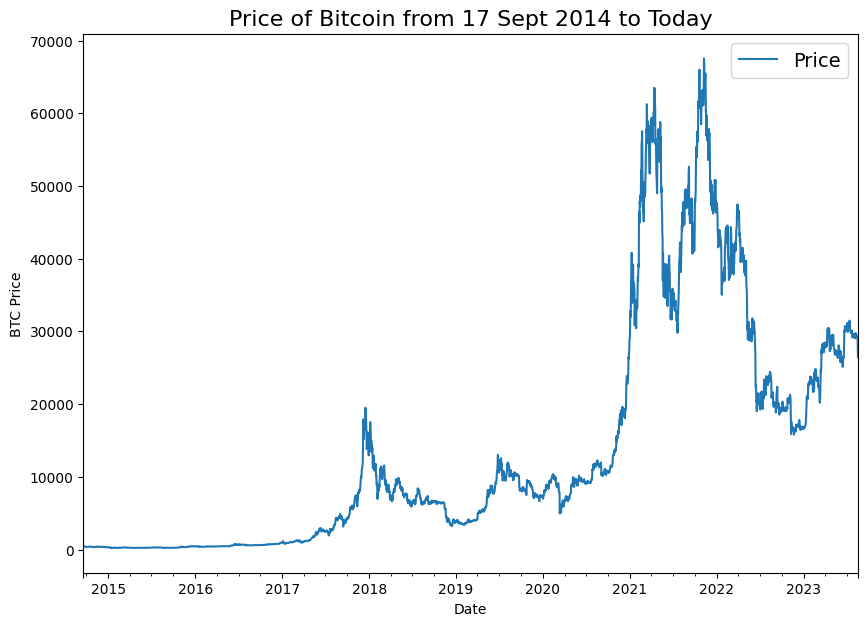

In [ ]:
bitcoin_price.plot(figsize=(10, 7))
plt.ylabel("BTC Price")
plt.title("Price of Bitcoin from 17 Sept 2014 to Today", fontsize=16)
plt.legend(fontsize=14);

## **Splitting Data into Train and Test set for Time series** **bold text**

In [ ]:
# Get bitcoin date array
timesteps = bitcoin_price.index.to_numpy()
prices = bitcoin_price["Price"].to_numpy()

timesteps[:10], prices[:10]

(array([Timestamp('2014-09-17 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-18 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-19 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-20 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-21 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-22 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-23 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-24 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-25 00:00:00+0000', tz='UTC'),
        Timestamp('2014-09-26 00:00:00+0000', tz='UTC')], dtype=object),
 array([457.33401489, 424.44000244, 394.79598999, 408.9039917 ,
        398.8210144 , 402.15200806, 435.79098511, 423.20498657,
        411.57400513, 404.42498779]))

In [ ]:
# Create train and test splits the right way for time series data
split_size = int(0.8 * len(prices)) # 80% train, 20% test

# Create train data splits (September 2014 to December 2021)
X_train, y_train = timesteps[:split_size], prices[:split_size]

# Create test data splits (January 2022 to August 2023)
X_test, y_test = timesteps[split_size:], prices[split_size:]

len(X_train), len(X_test), len(y_train), len(y_test)


(2606, 652, 2606, 652)

The plot shows the Data split into Train data and Test data.

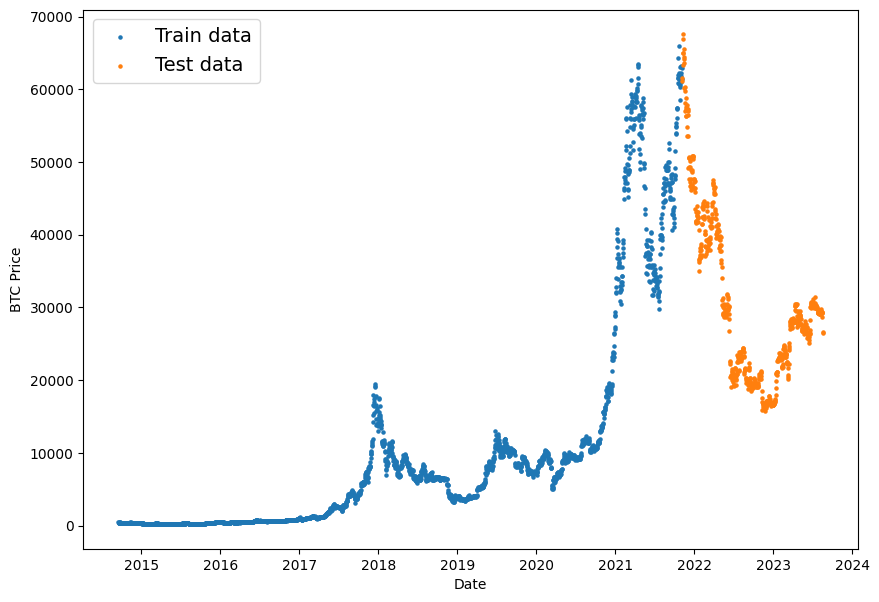

In [ ]:
# Plot splits
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, s=5, label="Train data")
plt.scatter(X_test, y_test, s=5, label="Test data")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.legend(fontsize=14)
plt.show();

## **Create our own plotting function (time_series_plot()).**

In [ ]:
# Create a function to plot time series data
def time_series_plot(timesteps, values, format='.', start=0, end=None, label=None):
  """
  Plots a timesteps (a series of points in time) against values (a series of values across timesteps).

  Parameters
  ---------
  timesteps : timesteps array
  values : array of values across time
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (setting a value will index from end of timesteps & values)
  label : label to show on plot of values
  """
  # Plot the series
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel("Time")
  plt.ylabel("BTC Price")
  if label:
    plt.legend(fontsize=14) # make label bigger
  plt.grid(True)

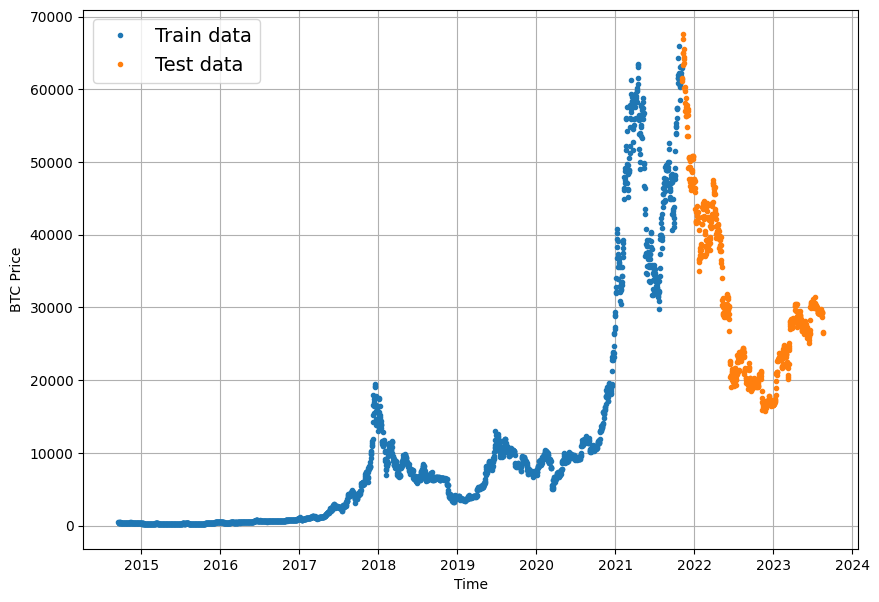

In [ ]:
# Try out our plotting function
plt.figure(figsize=(10, 7))
time_series_plot(timesteps=X_train, values=y_train, label="Train data")
time_series_plot(timesteps=X_test, values=y_test, label="Test data")

## **Modelling Experiments**
In this study, our main focus will be on adjusting the horizon size and window size.
  * **Horizon** = number of timesteps to predict into future
  * **Window** = number of timesteps from past used to predict **horizon**

For instance, if we aim to forecast the price of Bitcoin for tomorrow, we use the Bitcoin prices of the previous week. In this case, the horizon is 1 and the window is 7.


| Model Number | Model Type | Horizon size | Window size | Extra data |
| ----- | ----- | ----- | ----- | ----- |
| 0 | Naïve model (baseline) | NA | NA | NA |
| 1 | Dense Model | 1 | 7 | NA |
| 2 | Dense Model | 1 | 30 | NA |
| 3 | Dense Model | 7 | 30 | NA |
| 4 | Conv1D | 1 | 7 | NA |
| 5 | LSTM | 1 | 7 | NA |
| 6 | Dense Model (with multivariate data) | 1 | 7 | Block reward size |
| 7 | N-BEATs Algorithm | 1 | 7 | NA |
| 8 | Ensemble Model (multiple models optimized on different loss functions) | 1 | 7 | NA |
| 9 | Future prediction Dense model (model to predict future values) | 14 | Data | NA|


# **Model 0: Naïve forecast (baseline)**

One commonly used baseline model for time series forecasting is the naïve Bayes model (also called the [naïve forecast](https://otexts.com/fpp3/simple-methods.html#na%C3%AFve-method)), which requires no training. We will train and test this model using our dataset without setting any window or horizon sizes.

In [ ]:
# Create a naïve forecast
naive_forecast = y_test[:-1] # Naïve forecast includes every value excluding the last value
naive_forecast[:10], naive_forecast[-10:] # View frist 10 and last 10

(array([61125.67578125, 61527.48046875, 63326.98828125, 67566.828125  ,
        66971.828125  , 64995.23046875, 64949.9609375 , 64155.94140625,
        64469.52734375, 65466.83984375]),
 array([29765.4921875 , 29561.49414062, 29429.59179688, 29397.71484375,
        29415.96484375, 29282.9140625 , 29408.44335938, 29170.34765625,
        28701.77929688, 26664.55078125]))

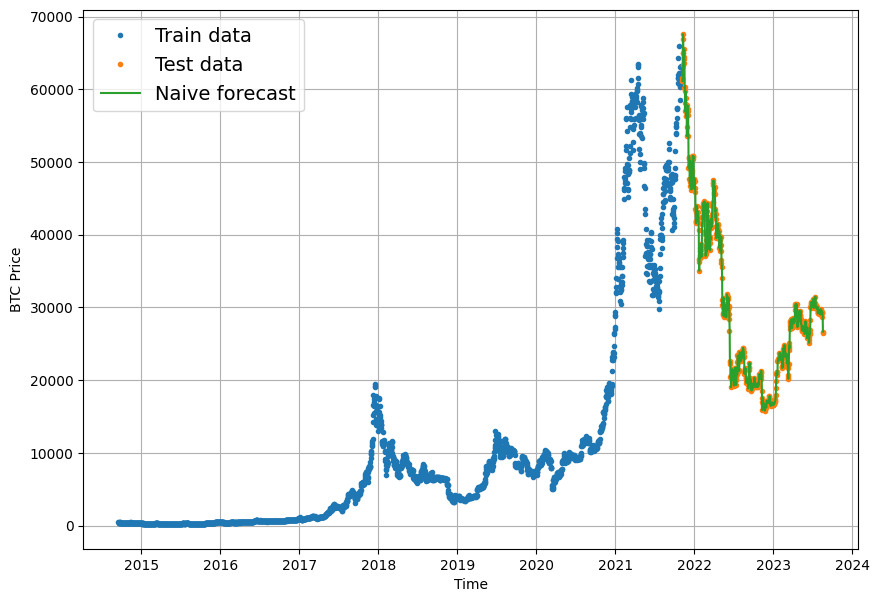

In [ ]:
# Plot naive forecast
plt.figure(figsize=(10, 7))
time_series_plot(timesteps=X_train, values=y_train, label="Train data")
time_series_plot(timesteps=X_test, values=y_test, label="Test data")
time_series_plot(timesteps=X_test[1:], values=naive_forecast, format="-", label="Naive forecast");

TLooks like the Naive Forecast follows the data pretty well.

Let's zoom in to take a better look.

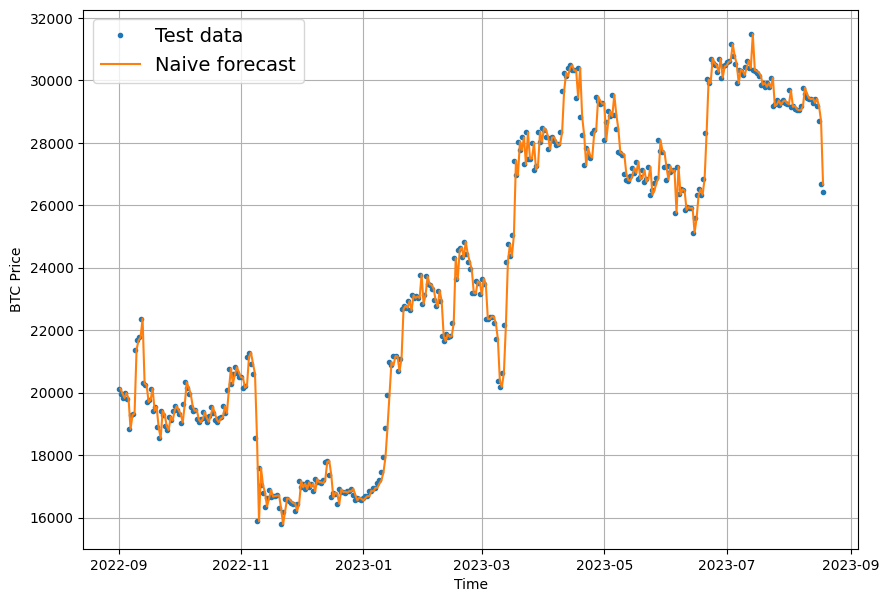

In [ ]:
plt.figure(figsize=(10, 7))
offset = 300 # offset the values by 300 timesteps
time_series_plot(timesteps=X_test, values=y_test, start=offset, label="Test data")
time_series_plot(timesteps=X_test[1:], values=naive_forecast, format="-", start=offset, label="Naive forecast");

Zooming in reveals that the naive forecast tracks the test data with slight variations in predicted prices.. This makes sense because the naive forecast predicts the next timestep value using the value of the previous timestep.

Forecast on the test data is completed, now let's evaluate its performance on test data.

## **Evaluating a time series model**
Time series forecasting often involves predicting a number (in our case, the price of Bitcoin).
*  **Resource:** We're going to be using several metrics to evaluate our different model's time series forecast accuracy. Many of them are sourced and explained mathematically and conceptually in [Forecasting: Principles and Practice](https://otexts.com/fpp3/accuracy.html).

### Scale-dependent errors

These are metrics which can be used to compare time series values and forecasts that are on the same scale.

For example, Bitcoin historical prices in USD veresus Bitcoin forecast values in USD.

| Metric | Details |
| ----- | ----- |
| **MAE** (mean absolute error) | Easy to interpret (a forecast is X amount different from actual amount). Forecast methods which minimises the MAE will lead to forecasts of the median. |
| **RMSE** (root mean square error) | Forecasts which minimise the RMSE lead to forecasts of the mean. |

### Percentage errors

Percentage errors do not have units, this means they can be used to compare forecasts across different datasets.

| **Metric** | **Details** |
| ----- | ----- |
| **MAPE** (mean absolute percentage error) | Most commonly used percentage error. May explode (not work) if y=0. |
| **sMAPE** (symmetric mean absolute percentage error) | Recommended not to be used by [Forecasting: Principles and Practice](https://otexts.com/fpp3/accuracy.html#percentage-errors), though it is used in forecasting competitions. |

### Scaled errors

Scaled errors are an alternative to percentage errors when comparing forecast performance across different time series.

| **Metric** | **Details** |
| ----- | ----- |
| **MASE** (mean absolute scaled error). | MASE equals one for the naive forecast (or very close to one). A forecast which performs better than the naïve should get <1 MASE. |

Since we're going to be evaluing a lot of models, let's write a function to help us calculate evaluation metrics on their forecasts.

Since TensorFlow doesn't have an inbuilt version of MASE (mean aboslute scaled error), let me custom it

Let's take inspiration from sktime's (Scikit-Learn for time series) [`MeanAbsoluteScaledError`](https://www.ibm.com/docs/en/cognos-analytics/11.1.0?topic=forecasting-statistical-details) class which calculates the MASE.

In [ ]:
def mean_absolute_scaled_error(y_true, y_pred):
  """
  Implement MASE (assuming no seasonality of data).
  """
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))

  # Find MAE of naive forecast (no seasonality)
  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1])) # our seasonality is 1 day (hence the shifting of 1 day)

  return mae / mae_naive_no_season

Let's put each of our different evaluation metrics together into a function.

In [ ]:
def evaluate_preds(y_true, y_pred):
  # Make sure float32 (for metric calculations)
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)

  # Calculate various metrics
  mae = tf.keras.metrics.mean_absolute_error(y_true, y_pred)
  mse = tf.keras.metrics.mean_squared_error(y_true, y_pred) # puts and emphasis on outliers (all errors get squared)
  rmse = tf.sqrt(mse)
  mape = tf.keras.metrics.mean_absolute_percentage_error(y_true, y_pred)
  mase = mean_absolute_scaled_error(y_true, y_pred)

  return {"mae": mae.numpy(),
          "mse": mse.numpy(),
          "rmse": rmse.numpy(),
          "mape": mape.numpy(),
          "mase": mase.numpy()}

In [ ]:
naive_results = evaluate_preds(y_true=y_test[1:],
                               y_pred=naive_forecast)
naive_results

{'mae': 627.6138,
 'mse': 975949.0,
 'rmse': 987.9013,
 'mape': 2.0476015,
 'mase': 0.99944675}

Now that we have the results of the baseline model, let's work to improve upon it.

Taking a look at the naïve forecast's MAE, it seems on average each forecast is ~$627 different than the actual Bitcoin price.

In [ ]:
# Find average price of Bitcoin in test dataset
tf.reduce_mean(y_test).numpy()

29835.437814537003

**Observation**:
* In the test dataset, the average price of Bitcoin is $29835.43. Noting that the highest price is more than three times this amount and the lowest price is more than four times lower, the average may not be the ideal metric here.

* Each prediction in naive forecast is on average off by: $627.



## Exploration of times series forecasting models


Since we've got a naïve bayes forecast baseline, it's time we start building models to try and beat it.

As I am focusing on TensorFlow and deep learning, I will be using TensorFlow to build deep learning models to try and improve on our naïve forecasting results.


## Format Data Part 2: Windowing dataset

Windowing is a method to turn a time series dataset into **supervised learning problem**.

In other words, we want to use windows of the past to predict the future.

For example for a univariate time series, windowing for one week (`window=7`) to predict the next single value (`horizon=1`) might look like:

```
Window for one week (univariate time series)

[0, 1, 2, 3, 4, 5, 6] -> [7]
[1, 2, 3, 4, 5, 6, 7] -> [8]
[2, 3, 4, 5, 6, 7, 8] -> [9]
```

Let's build some functions which take in a univariate time series and turn it into windows and horizons of specified sizes. Let's start with the default horizon size of 1 and a window size of 7.

In [ ]:
HORIZON = 1 # predict 1 step at a time
WINDOW_SIZE = 7 # use a week worth of timesteps to predict the horizon

Now we'll write a function to take in an array and turn it into a window and horizon.

In [ ]:
# Create function to label windowed data
def get_labelled_windows(x, horizon=1):
  """
  Creates labels for windowed dataset.

  E.g. if horizon=1 (default)
  Input: [1, 2, 3, 4, 5, 6] -> Output: ([1, 2, 3, 4, 5], [6])
  """
  return x[:, :-horizon], x[:, -horizon:]

In [ ]:
# Test out the window labelling function
test_window, test_label = get_labelled_windows(tf.expand_dims(tf.range(8)+1, axis=0), horizon=HORIZON)
print(f"Window: {tf.squeeze(test_window).numpy()} -> Label: {tf.squeeze(test_label).numpy()}")

Window: [1 2 3 4 5 6 7] -> Label: 8


Now we need a way to make windows for an entire time series.

We could do this with Python for loops, however, for large time series, that'd be quite slow.

To speed things up, we'll leverage [NumPy's array indexing](https://numpy.org/doc/stable/reference/arrays.indexing.html).

Let's write a function which:
1. Creates a window step of specific window size, for example: `[[0, 1, 2, 3, 4, 5, 6, 7]]`
2. Uses NumPy indexing to create a 2D of multiple window steps, for example:
```
[[0, 1, 2, 3, 4, 5, 6, 7],
 [1, 2, 3, 4, 5, 6, 7, 8],
 [2, 3, 4, 5, 6, 7, 8, 9]]
```
3. Uses the 2D array of multuple window steps to index on a target series
4. Uses the `get_labelled_windows()` function we created above to turn the window steps into windows with a specified horizon

>  **Resource:** The function created below has been adapted from Syafiq Kamarul Azman's article [*Fast and Robust Sliding Window Vectorization with NumPy*](https://towardsdatascience.com/fast-and-robust-sliding-window-vectorization-with-numpy-3ad950ed62f5).

In [ ]:
# Create function to view NumPy arrays as windows
def make_windows(x, window_size=7, horizon=1):
  """
  Turns a 1D array into a 2D array of sequential windows of window_size.
  """
  # 1. Create a window of specific window_size (add the horizon on the end for later labelling)
  window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)
  # print(f"Window step:\n {window_step}")

  # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing)
  window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T # create 2D array of windows of size window_size
  # print(f"Window indexes:\n {window_indexes[:3], window_indexes[-3:], window_indexes.shape}")

  # 3. Index on the target array (time series) with 2D array of multiple window steps
  windowed_array = x[window_indexes]

  # 4. Get the labelled windows
  windows, labels = get_labelled_windows(windowed_array, horizon=horizon)

  return windows, labels

In [ ]:
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(3251, 3251)

In [ ]:
# View the first 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i]} -> Label: {full_labels[i]}")

Window: [457.33401489 424.44000244 394.79598999 408.9039917  398.8210144
 402.15200806 435.79098511] -> Label: [423.20498657]
Window: [424.44000244 394.79598999 408.9039917  398.8210144  402.15200806
 435.79098511 423.20498657] -> Label: [411.57400513]
Window: [394.79598999 408.9039917  398.8210144  402.15200806 435.79098511
 423.20498657 411.57400513] -> Label: [404.42498779]


In [ ]:
# View the last 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i-3]} -> Label: {full_labels[i-3]}")

Window: [29561.49414062 29429.59179688 29397.71484375 29415.96484375
 29282.9140625  29408.44335938 29170.34765625] -> Label: [28701.77929688]
Window: [29429.59179688 29397.71484375 29415.96484375 29282.9140625
 29408.44335938 29170.34765625 28701.77929688] -> Label: [26664.55078125]
Window: [29397.71484375 29415.96484375 29282.9140625  29408.44335938
 29170.34765625 28701.77929688 26664.55078125] -> Label: [26424.28320312]


## Turning windows into training and test sets



Time to turn our windows into training and test splits.

We could've windowed our existing training and test splits, however, with the nature of windowing (windowing often requires an offset at some point in the data), it usually works better to window the data first, then split it into training and test sets.

Let's write a function which takes in full sets of windows and their labels and splits them into train and test splits.

In [ ]:
# Make the train/test splits
def make_train_test_splits(windows, labels, test_split=0.2):
  """
  Splits matching pairs of windows and labels into train and test splits.
  """
  split_size = int(len(windows) * (1-test_split)) # this will default to 80% train/20% test
  train_windows = windows[:split_size]
  train_labels = labels[:split_size]
  test_windows = windows[split_size:]
  test_labels = labels[split_size:]
  return train_windows, test_windows, train_labels, test_labels

In [ ]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2600, 651, 2600, 651)

Notice the default split of 80% training data and 20% testing data (this split can be adjusted if needed).

In [ ]:
train_windows[:5], train_labels[:5]

(array([[457.33401489, 424.44000244, 394.79598999, 408.9039917 ,
         398.8210144 , 402.15200806, 435.79098511],
        [424.44000244, 394.79598999, 408.9039917 , 398.8210144 ,
         402.15200806, 435.79098511, 423.20498657],
        [394.79598999, 408.9039917 , 398.8210144 , 402.15200806,
         435.79098511, 423.20498657, 411.57400513],
        [408.9039917 , 398.8210144 , 402.15200806, 435.79098511,
         423.20498657, 411.57400513, 404.42498779],
        [398.8210144 , 402.15200806, 435.79098511, 423.20498657,
         411.57400513, 404.42498779, 399.51998901]]),
 array([[423.20498657],
        [411.57400513],
        [404.42498779],
        [399.51998901],
        [377.18099976]]))

## Make a modelling checkpoint

The `ModelCheckpoint` callback will monitor our model's performance during training and save the best model to file by setting `save_best_only=True`.

That way when evaluating our model we could restore its best performing configuration from file.

>  **Note:** Because of the size of the dataset (smaller than usual), you'll notice our modelling experiment results fluctuate quite a bit during training (hence the implementation of the `ModelCheckpoint` callback to save the best model).

Because we're going to be running multiple experiments, it makes sense to keep track of them by saving models to file under different names. Let's write a function to create a `ModelCheckpoint` callback.

In [ ]:
import os

# Create a function to implement a ModelCheckpoint callback with a specific filename
def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path, model_name), # create filepath to save model
                                            verbose=0, # only output a limited amount of text
                                            save_best_only=True) # save only the best model to file

## Model 1: Dense model (window = 7, horizon = 1)

We're going to start by keeping it simple, `model_1` will have:
* A single dense layer with 128 hidden units and ReLU (rectified linear unit) activation
* An output layer with linear activation (or no activation)
* Adam optimizer and MAE loss function
* Batch size of 128
* 100 epochs


> **Note**: As always, many of the values for machine learning problems are experimental. A reminder that the values you can set yourself in a machine learning algorithm (the hidden units, the batch size, horizon size, window size) are called hyperparameters. And experimenting to find the best values for hyperparameters is called hyperparameter tuning. Where as parameters learned by a model itself (patterns in the data, formally called weights & biases) are referred to as parameters.


Let's import TensorFlow and build our first deep learning model for time series.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Set random seed for as reproducible results as possible
tf.random.set_seed(42)

# Construct model
model_1 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON, activation="linear") # linear activation is the same as having no activation
], name="model_1_dense") # give the model a name so we can save it

# Compile model
model_1.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"]) # we don't necessarily need this when the loss function is already MAE

# Fit model
model_1.fit(x=train_windows, # train windows of 7 timesteps of Bitcoin prices
            y=train_labels, # horizon value of 1 (using the previous 7 timesteps to predict next day)
            epochs=100,
            verbose=1,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_1.name)]) # create ModelCheckpoint callback to save best model

Epoch 1/100
17/21 [=======================>......] - ETA: 0s - loss: 4286.3101 - mae: 4286.3101 

21/21 [==============================] - 3s 40ms/step - loss: 3857.2339 - mae: 3857.2339 - val_loss: 4978.4111 - val_mae: 4978.4111
Epoch 2/100
20/21 [===========================>..] - ETA: 0s - loss: 789.3750 - mae: 789.3750  

21/21 [==============================] - 1s 40ms/step - loss: 783.3116 - mae: 783.3116 - val_loss: 1734.4274 - val_mae: 1734.4274
Epoch 3/100
12/21 [================>.............] - ETA: 0s - loss: 475.2377 - mae: 475.2377

21/21 [==============================] - 2s 104ms/step - loss: 480.0860 - mae: 480.0860 - val_loss: 923.7036 - val_mae: 923.7036
Epoch 4/100
21/21 [==============================] - 0s 14ms/step - loss: 431.3482 - mae: 431.3482 - val_loss: 982.4869 - val_mae: 982.4869
Epoch 5/100
21/21 [==============================] - 0s 14ms/step - loss: 409.5506 - mae: 409.5506 - val_loss: 997.4782 - val_mae: 997.4782
Epoch 6/100
14/21 [===================>..........] - ETA: 0s - loss: 394.0675 - mae: 394.0675

21/21 [==============================] - 1s 52ms/step - loss: 397.8237 - mae: 397.8237 - val_loss: 810.4322 - val_mae: 810.4322
Epoch 7/100
21/21 [==============================] - 0s 8ms/step - loss: 397.5855 - mae: 397.5855 - val_loss: 869.7377 - val_mae: 869.7377
Epoch 8/100
13/21 [=================>............] - ETA: 0s - loss: 422.2721 - mae: 422.2721

...

21/21 [==============================] - 1s 25ms/step - loss: 338.4910 - mae: 338.4910 - val_loss: 646.8858 - val_mae: 646.8858
Epoch 73/100
21/21 [==============================] - 0s 5ms/step - loss: 300.8551 - mae: 300.8551 - val_loss: 686.8818 - val_mae: 686.8818
Epoch 74/100
21/21 [==============================] - 0s 5ms/step - loss: 306.3481 - mae: 306.3481 - val_loss: 648.7458 - val_mae: 648.7458
Epoch 75/100
21/21 [==============================] - 0s 5ms/step - loss: 297.6604 - mae: 297.6604 - val_loss: 669.7282 - val_mae: 669.7282
Epoch 76/100
21/21 [==============================] - 0s 4ms/step - loss: 310.8753 - mae: 310.8753 - val_loss: 767.1125 - val_mae: 767.1125
Epoch 77/100
21/21 [==============================] - 0s 5ms/step - loss: 308.8121 - mae: 308.8121 - val_loss: 787.4126 - val_mae: 787.4126
Epoch 78/100
20/21 [===========================>..] - ETA: 0s - loss: 317.1823 - mae: 317.1823

21/21 [==============================] - 1s 28ms/step - loss: 316.4554 - mae: 316.4554 - val_loss: 644.1032 - val_mae: 644.1032
Epoch 79/100
21/21 [==============================] - 0s 6ms/step - loss: 307.9101 - mae: 307.9101 - val_loss: 646.4428 - val_mae: 646.4428
Epoch 80/100
21/21 [==============================] - 0s 7ms/step - loss: 307.3818 - mae: 307.3818 - val_loss: 705.1287 - val_mae: 705.1287
Epoch 81/100
21/21 [==============================] - 0s 6ms/step - loss: 302.2337 - mae: 302.2337 - val_loss: 680.3230 - val_mae: 680.3230
Epoch 82/100
21/21 [==============================] - 0s 7ms/step - loss: 305.7159 - mae: 305.7159 - val_loss: 923.3780 - val_mae: 923.3780
Epoch 83/100
21/21 [==============================] - 0s 6ms/step - loss: 329.3657 - mae: 329.3657 - val_loss: 660.2454 - val_mae: 660.2454
Epoch 84/100
21/21 [==============================] - 0s 6ms/step - loss: 306.4495 - mae: 306.4495 - val_loss: 659.1995 - val_mae: 659.1995
Epoch 85/100
14/21 [============

21/21 [==============================] - 1s 39ms/step - loss: 309.0263 - mae: 309.0263 - val_loss: 641.1381 - val_mae: 641.1381
Epoch 86/100
21/21 [==============================] - 0s 6ms/step - loss: 344.4255 - mae: 344.4255 - val_loss: 850.2822 - val_mae: 850.2822
Epoch 87/100
21/21 [==============================] - 0s 6ms/step - loss: 312.4086 - mae: 312.4086 - val_loss: 788.6687 - val_mae: 788.6687
Epoch 88/100
21/21 [==============================] - 0s 7ms/step - loss: 314.5658 - mae: 314.5658 - val_loss: 645.9589 - val_mae: 645.9589
Epoch 89/100
21/21 [==============================] - 0s 7ms/step - loss: 306.5992 - mae: 306.5992 - val_loss: 648.2072 - val_mae: 648.2072
Epoch 90/100
21/21 [==============================] - 0s 5ms/step - loss: 311.9514 - mae: 311.9514 - val_loss: 777.1457 - val_mae: 777.1457
Epoch 91/100
19/21 [==========================>...] - ETA: 0s - loss: 318.7018 - mae: 318.7018

21/21 [==============================] - 1s 26ms/step - loss: 317.3031 - mae: 317.3031 - val_loss: 640.5157 - val_mae: 640.5157
Epoch 92/100
21/21 [==============================] - 0s 5ms/step - loss: 301.4385 - mae: 301.4385 - val_loss: 654.1831 - val_mae: 654.1831
Epoch 93/100
21/21 [==============================] - 0s 5ms/step - loss: 331.6586 - mae: 331.6586 - val_loss: 707.0164 - val_mae: 707.0164
Epoch 94/100
21/21 [==============================] - 0s 5ms/step - loss: 312.9008 - mae: 312.9008 - val_loss: 823.5643 - val_mae: 823.5643
Epoch 95/100
21/21 [==============================] - 0s 5ms/step - loss: 310.6047 - mae: 310.6047 - val_loss: 646.6174 - val_mae: 646.6174
Epoch 96/100
21/21 [==============================] - 0s 5ms/step - loss: 309.1010 - mae: 309.1010 - val_loss: 745.4239 - val_mae: 745.4239
Epoch 97/100
16/21 [=====================>........] - ETA: 0s - loss: 298.9826 - mae: 298.9826

21/21 [==============================] - 1s 27ms/step - loss: 300.2307 - mae: 300.2307 - val_loss: 640.1294 - val_mae: 640.1294
Epoch 98/100
21/21 [==============================] - 0s 6ms/step - loss: 307.4264 - mae: 307.4264 - val_loss: 852.9261 - val_mae: 852.9261
Epoch 99/100
21/21 [==============================] - 0s 9ms/step - loss: 314.4796 - mae: 314.4796 - val_loss: 655.5120 - val_mae: 655.5120
Epoch 100/100
21/21 [==============================] - 0s 7ms/step - loss: 315.4600 - mae: 315.4600 - val_loss: 794.7685 - val_mae: 794.7685


In [ ]:
# Evaluate model on test data
model_1.evaluate(test_windows, test_labels)

21/21 [==============================] - 0s 2ms/step - loss: 794.7684 - mae: 794.7684


[794.7683715820312, 794.7683715820312]

In [ ]:
# Load in saved best performing model_1 and evaluate on test data
model_1 = tf.keras.models.load_model("model_experiments/model_1_dense")
model_1.evaluate(test_windows, test_labels)

21/21 [==============================] - 0s 3ms/step - loss: 640.1293 - mae: 640.1293


[640.1293334960938, 640.1293334960938]

## Making forecasts with a model:

Since we're going to be running more modelling experiments, let's write a function which:
1. Takes in a trained model (just like `model_1`)
2. Takes in some input data (just like the data the model was trained on)
3. Passes the input data to the model's `predict()` method
4. Returns the predictions

In [ ]:
def make_preds(model, input_data):
  """
  Uses model to make predictions on input_data.

  Parameters
  ----------
  model: trained model
  input_data: windowed input data (same kind of data model was trained on)

  Returns model predictions on input_data.
  """
  forecast = model.predict(input_data)
  return tf.squeeze(forecast) # return 1D array of predictions

In [ ]:
# Make predictions using model_1 on the test dataset and view the results
model_1_preds = make_preds(model_1, test_windows)
len(model_1_preds), model_1_preds[:10]

21/21 [==============================] - 0s 1ms/step


(651,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([61171.047, 61551.44 , 63052.88 , 67074.2  , 67350.8  , 65651.84 ,
        65071.29 , 64382.773, 64296.004, 65218.473], dtype=float32)>)



>  **Note**: With these outputs, our model isn't forecasting yet. It's only making predictions on the test dataset. Forecasting would involve a model making predictions into the future, however, the test dataset is only a pseudofuture.



Now we've got some prediction values, let's use the evaluate_preds() we created before to compare them to the ground truth.

In [ ]:
# Evaluate preds
model_1_results = evaluate_preds(y_true=tf.squeeze(test_labels), # reduce to right shape
                                 y_pred=model_1_preds)
model_1_results

{'mae': 640.1293,
 'mse': 1014065.8,
 'rmse': 1007.00836,
 'mape': 2.087862,
 'mase': 1.0193771}

It looks like our naïve bayes forecast model beats our first deep model on nearly every metric.

That goes to show the power of the naïve model and the reason for having a baseline for any machine learning project.

Let us visualizing the results.

Let's use the plot_time_series() function to plot model_1_preds against the test data.

As mentioned before, they're on the test dataset. So they're not actual forecasts

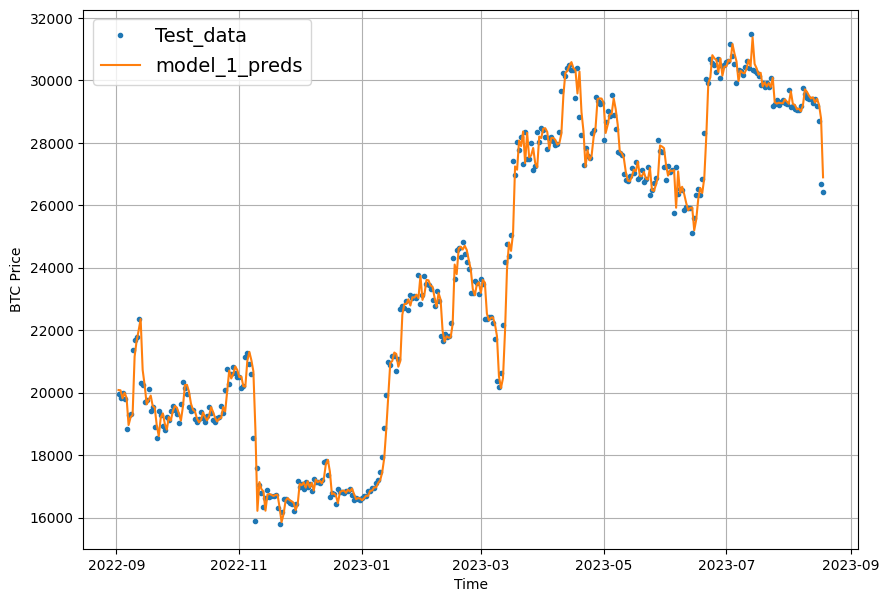

In [ ]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset and index into test_labels to ensure correct plotting
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_1_preds, start=offset, format="-", label="model_1_preds")

## Model 2: Dense model (window = 30, horizon = 1)

A naïve model is currently beating our handcrafted deep learning model.

We'll keep the previous model architecture but use a window size of 30.

In other words, we'll use the previous 30 days of Bitcoin prices to try and predict the next day price.

>  **Note:** Recall from before, the window size (how many timesteps to use to fuel a forecast) and the horizon (how many timesteps to predict into the future) are **hyperparameters**. This means you can tune them to try and find values will result in better performance.

We'll start our second modelling experiment by preparing datasets using the functions we created earlier.

In [ ]:
HORIZON = 1 # predict one step at a time
WINDOW_SIZE = 30 # use 30 timesteps in the past

In [ ]:
# Make windowed data with appropriate horizon and window sizes
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(3228, 3228)

In [ ]:
# Make train and testing windows
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows=full_windows, labels=full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2582, 646, 2582, 646)

Let's construct model_2, a model with the same architecture as model_1 as well as the same training routine.

In [ ]:
tf.random.set_seed(42)

# Create model (same model as model 1 but data input will be different)
model_2 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON) # need to predict horizon number of steps into the future
], name="model_2_dense")

model_2.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

model_2.fit(train_windows,
            train_labels,
            epochs=100,
            batch_size=128,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_2.name)])

Let's evaluate our model's performance.

In [ ]:
# Evaluate model 2 preds
model_2.evaluate(test_windows, test_labels)

21/21 [==============================] - 0s 2ms/step - loss: 823.9213


823.9212646484375

You'll notice the model achieves the same val_loss (in this case, this is MAE) as the last epoch.

But if we load in the version of model_1 which was saved to file using the ModelCheckpoint callback, we should see an improvement in results.

In [ ]:
# Load in best performing model
model_2 = tf.keras.models.load_model("model_experiments/model_2_dense/")
model_2.evaluate(test_windows, test_labels)

21/21 [==============================] - 0s 2ms/step - loss: 719.7209


719.720947265625

In [ ]:
# Get forecast predictions
model_2_preds = make_preds(model_2,
                           input_data=test_windows)

21/21 [==============================] - 0s 1ms/step


In [ ]:
# Evaluate results for model 2 predictions
model_2_results = evaluate_preds(y_true=tf.squeeze(test_labels), # remove 1 dimension of test labels
                                 y_pred=model_2_preds)
model_2_results

{'mae': 719.72095,
 'mse': 1168329.8,
 'rmse': 1080.8931,
 'mape': 2.3631995,
 'mase': 1.1619486}

It looks like model_2 performs worse than the naïve model as well as model_1.

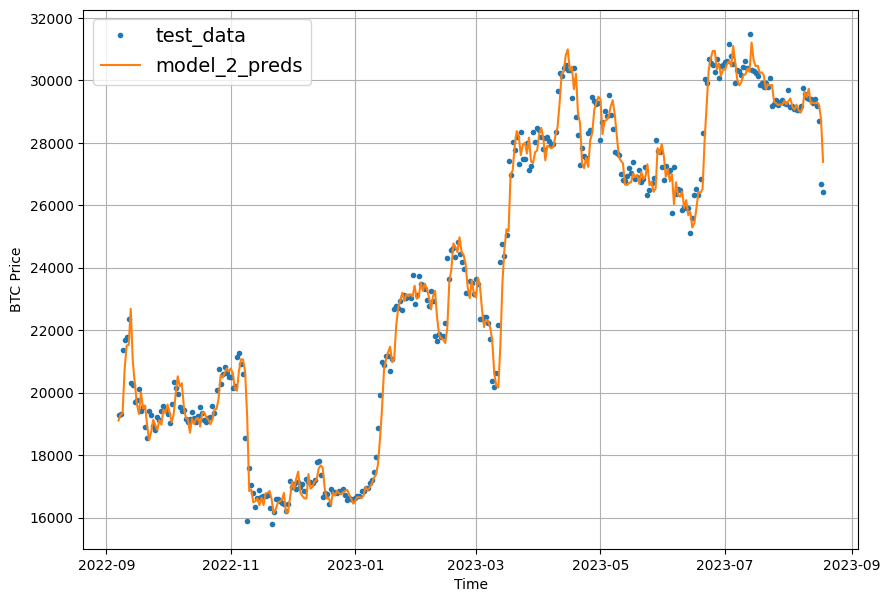

In [ ]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_2_preds, start=offset, format="-", label="model_2_preds")

## Model 3: Dense model (window = 30, horizon = 7)

Let's try and predict 7 days ahead given the previous 30 days.

First, we'll update the `HORIZON` and `WINDOW_SIZE` variables and create windowed data.

In [ ]:
HORIZON = 7
WINDOW_SIZE = 30

full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(3222, 3222)

In [ ]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows=full_windows, labels=full_labels, test_split=0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2577, 645, 2577, 645)

let's build, compile, fit and evaluate a model.

In [ ]:
tf.random.set_seed(42)

# Create model (same as model_1 except with different data input size)
model_3 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON)
], name="model_3_dense")

model_3.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

model_3.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_3.name)])

In [ ]:
# How did our model with a larger window size and horizon go?
model_3.evaluate(test_windows, test_labels)

21/21 [==============================] - 0s 2ms/step - loss: 1397.2902


1397.2901611328125

To compare apples to apples (best performing model to best performing model), we've got to load in the best version of model_3.

In [ ]:
# Load in best version of model_3 and evaluate
model_3 = tf.keras.models.load_model("model_experiments/model_3_dense/")
model_3.evaluate(test_windows, test_labels)

21/21 [==============================] - 0s 2ms/step - loss: 1377.6857


1377.6856689453125

In this case, the error will be higher because we're predicting 7 steps at a time.

This makes sense though because the further you try and predict, the larger your error will be (think of trying to predict the weather 7 days in advance).

Let's make predictions with our model using the make_preds() function and evaluate them using the evaluate_preds() function.

In [ ]:
# The predictions are going to be 7 steps at a time (this is the HORIZON size)
model_3_preds = make_preds(model_3,
                           input_data=test_windows)
model_3_preds[:5]

21/21 [==============================] - 0s 1ms/step


<tf.Tensor: shape=(5, 7), dtype=float32, numpy=
array([[62170.625, 62054.152, 61674.445, 60971.43 , 62410.043, 62988.902,
        61252.75 ],
       [62077.79 , 62591.504, 60337.05 , 60861.25 , 62479.965, 62602.15 ,
        61761.266],
       [60334.953, 62614.05 , 61625.812, 62429.633, 63253.23 , 63718.113,
        61318.176],
       [65688.87 , 65168.375, 64258.566, 65409.105, 65971.875, 65572.06 ,
        64841.797],
       [66869.586, 67457.43 , 66634.36 , 66446.34 , 67048.875, 67875.21 ,
        65543.84 ]], dtype=float32)>

In [ ]:
# Calculate model_3 results - these are going to be multi-dimensional because
# we're trying to predict more than one step at a time.
model_3_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_3_preds)
model_3_results

{'mae': array([3036.8855 , 3389.3333 , 3326.0269 ,  898.88   , 2874.1472 ,
        3752.3293 , 3879.0425 , 3809.944  , 3974.2573 , 5308.184  ,
        5802.3096 , 3774.2327 , 2759.4675 , 1403.1272 , 1287.3839 ,
        2405.5842 , 2140.284  , 1750.6345 , 1492.3275 , 1170.2467 ,
        1449.0608 , 1519.6908 , 2722.0798 , 3545.0469 , 3910.5825 ,
        5102.4556 , 6041.57   , 6859.9634 , 5041.3003 , 1869.2216 ,
        1628.1613 , 1183.8644 , 1458.7517 , 1979.2667 , 1738.4799 ,
        1447.0731 , 1114.0284 , 1632.6736 , 1182.4124 , 1163.5586 ,
        1164.1619 , 1173.8281 , 2264.2395 , 2778.812  , 3673.7996 ,
        4549.121  , 2624.8386 , 1829.6669 , 1559.9169 , 2308.6746 ,
        2131.0325 , 2649.8477 , 3430.559  , 2009.7706 , 1574.6222 ,
        1489.9989 , 1888.6858 , 2208.2527 , 3588.8254 , 3726.433  ,
        3568.1875 , 2289.3738 , 1066.654  ,  864.78516, 1176.7578 ,
        1810.3566 , 2234.8325 , 1193.3622 ,  601.40125,  774.47375,
        1695.5352 , 2639.7114 , 3784.7747

## Make our evaluation function work for larger horizons

You'll notice the outputs for `model_3_results` are multi-dimensional.

This is because the predictions are getting evaluated across the `HORIZON` timesteps (7 predictions at a time).

To fix this, let's adjust our `evaluate_preds()` function to work with multiple shapes of data.

In [ ]:
def evaluate_preds(y_true, y_pred):
  # Make sure float32 (for metric calculations)
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)

  # Calculate various metrics
  mae = tf.keras.metrics.mean_absolute_error(y_true, y_pred)
  mse = tf.keras.metrics.mean_squared_error(y_true, y_pred)
  rmse = tf.sqrt(mse)
  mape = tf.keras.metrics.mean_absolute_percentage_error(y_true, y_pred)
  mase = mean_absolute_scaled_error(y_true, y_pred)

  # Account for different sized metrics (for longer horizons, reduce to single number)
  if mae.ndim > 0: # if mae isn't already a scalar, reduce it to one by aggregating tensors to mean
    mae = tf.reduce_mean(mae)
    mse = tf.reduce_mean(mse)
    rmse = tf.reduce_mean(rmse)
    mape = tf.reduce_mean(mape)
    mase = tf.reduce_mean(mase)

  return {"mae": mae.numpy(),
          "mse": mse.numpy(),
          "rmse": rmse.numpy(),
          "mape": mape.numpy(),
          "mase": mase.numpy()}

Now we've updated evaluate_preds() to work with multiple shapes.

In [ ]:
# Get model_3 results aggregated to single values
model_3_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_3_preds)
model_3_results

{'mae': 1377.6855,
 'mse': 4357377.0,
 'rmse': 1589.4985,
 'mape': 4.5680165,
 'mase': 2.2169394}

Time to visualize.

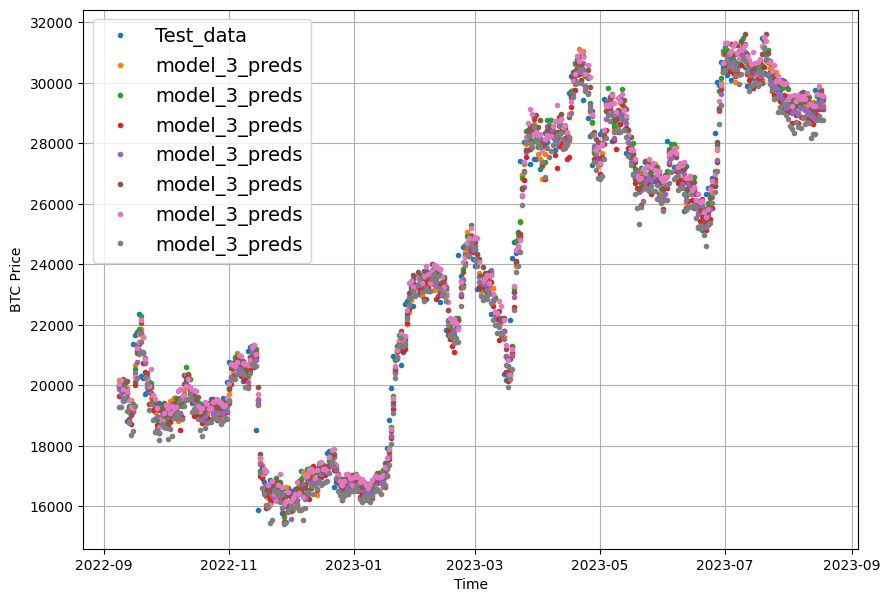

In [ ]:
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
# Checking the shape of model_3_preds results in [n_test_samples, HORIZON] (this will screw up the plot)
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_3_preds, start=offset, label="model_3_preds")

When we try to plot our multi-horizon predicts, we get a funky looking plot.

Again, we can fix this by aggregating our model's predictions.

>  **Note:** Aggregating the predictions (e.g. reducing a 7-day horizon to one value such as the mean) loses information from the original prediction. As in, the model predictions were trained to be made for 7-days but by reducing them to one, we gain the ability to plot them visually but we lose the extra information contained across multiple days.

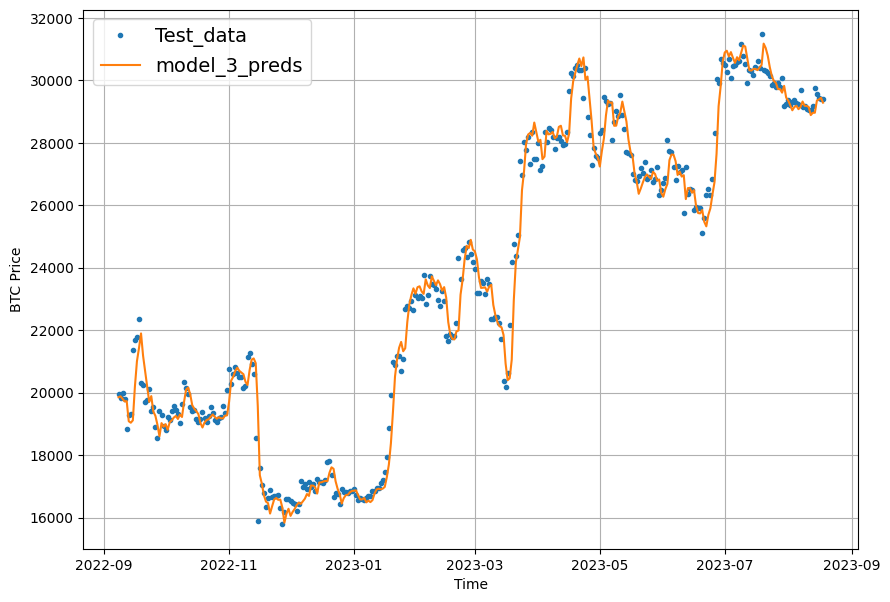

In [ ]:
offset = 300
plt.figure(figsize=(10, 7))
# Plot model_3_preds by aggregating them (note: this condenses information so the preds will look fruther ahead than the test data)
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=test_labels[:, 0],
                 start=offset,
                 label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=tf.reduce_mean(model_3_preds, axis=1),
                 format="-",
                 start=offset,
                 label="model_3_preds")


So far, we've trained 3 models which use the same architecture but use different data inputs.

Let's compare them with the naïve model to see which model is performing the best so far.

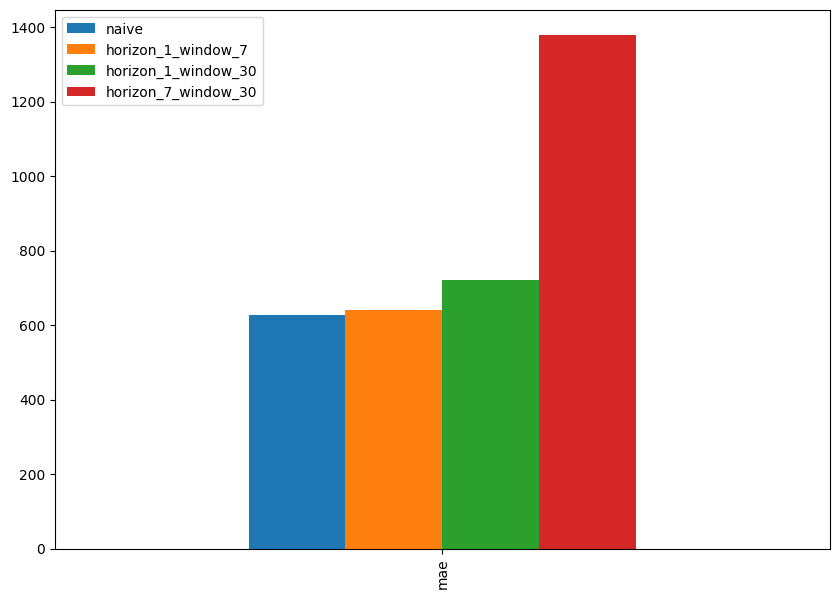

In [ ]:
pd.DataFrame({"naive": naive_results["mae"],
              "horizon_1_window_7": model_1_results["mae"],
              "horizon_1_window_30": model_2_results["mae"],
              "horizon_7_window_30": model_3_results["mae"]}, index=["mae"]).plot(figsize=(10, 7), kind="bar");

The naïve model is performing best (it's very hard to beat a naïve model in open systems) but the dense model with a horizon of 1 and a window size of 7 looks to be performing closest.

Because of this, let's use `HORIZON=1` and `WINDOW_SIZE=7` for our next series of modelling experiments (in other words, we'll use the previous week of Bitcoin prices to try and predict the next day).

## Model 4: Conv1D

Let's use a Conv1D model, as it can be used for seq2seq (sequence to sequence) problems.

In our case, the input sequence is the previous 7 days of Bitcoin price data and the output is the next day (in seq2seq terms this is called a many to one problem).


Before we build a Conv1D model, let's recreate our datasets.

In [ ]:
HORIZON = 1 # predict next day
WINDOW_SIZE = 7 # use previous week worth of data

In [ ]:
# Create windowed dataset
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(3251, 3251)

In [ ]:
# Create train/test splits
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2600, 651, 2600, 651)

since we're going to be using [Conv1D layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv1D), we need to make sure our input shapes are correct.

The Conv1D layer in TensorFlow takes an input of: `(batch_size, timesteps, input_dim)`.

In our case, the `batch_size` (by default this is 32 but we can change it) is handled for us but the other values will be:
* `timesteps = WINDOW_SIZE` - the `timesteps` is also often referred to as `features`, our features are the previous `WINDOW_SIZE` values of Bitcoin
* `input_dim = HORIZON` - our model views `WINDOW_SIZE` (one week) worth of data at a time to predict `HORIZON` (one day)

Right now, our data has the `timesteps` dimension ready but we'll have to adjust it to have the `input_dim` dimension.

In [ ]:
# Check data sample shapes
train_windows[0].shape # returns (WINDOW_SIZE, )

(7,)

To fix this, we could adjust the shape of all of our `train_windows` or we could use a [`tf.keras.layers.Lamdba`](https://keras.io/api/layers/core_layers/lambda/) (called a Lambda layer) to do this for us in our model.

The Lambda layer wraps a function into a layer which can be used with a model.

Let's try it out.

In [ ]:
# Before we pass our data to the Conv1D layer, we have to reshape it in order to make sure it works
x = tf.constant(train_windows[0])
expand_dims_layer = layers.Lambda(lambda x: tf.expand_dims(x, axis=1)) # add an extra dimension for timesteps
print(f"Original shape: {x.shape}") # (WINDOW_SIZE)
print(f"Expanded shape: {expand_dims_layer(x).shape}") # (WINDOW_SIZE, input_dim)
print(f"Original values with expanded shape:\n {expand_dims_layer(x)}")

Original shape: (7,)
Expanded shape: (7, 1)
Original values with expanded shape:
 [[457.334]
 [424.44 ]
 [394.796]
 [408.904]
 [398.821]
 [402.152]
 [435.791]]


Now we've got a Lambda layer, let's build, compile, fit and evaluate a Conv1D model on our data.

>  **Note:** If you run the model below without the Lambda layer, you'll get an input shape error (one of the most common errors when building neural networks).

In [ ]:
tf.random.set_seed(42)

# Create model
model_4 = tf.keras.Sequential([
  # Create Lambda layer to reshape inputs, without this layer, the model will error
  layers.Lambda(lambda x: tf.expand_dims(x, axis=1)), # resize the inputs to adjust for window size / Conv1D 3D input requirements
  layers.Conv1D(filters=128, kernel_size=5, padding="causal", activation="relu"),
  layers.Dense(HORIZON)
], name="model_4_conv1D")

# Compile model
model_4.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Fit model
model_4.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_4.name)])

In [ ]:
model_4.summary()

Model: "model_4_conv1D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda_1 (Lambda)           (None, 1, 7)              0         
                                                                 
 conv1d (Conv1D)             (None, 1, 128)            4608      
                                                                 
 dense_6 (Dense)             (None, 1, 1)              129       
                                                                 
Total params: 4,737
Trainable params: 4,737
Non-trainable params: 0
_________________________________________________________________


The Lambda layer appears the same as any other regular layer.

Now, let's evaluate the Conv1D model.

In [ ]:
# Load in best performing Conv1D model and evaluate it on the test data
model_4 = tf.keras.models.load_model("model_experiments/model_4_conv1D")
model_4.evaluate(test_windows, test_labels)

21/21 [==============================] - 0s 2ms/step - loss: 666.3223


666.322265625

In [ ]:
# Make predictions
model_4_preds = make_preds(model_4, test_windows)
model_4_preds[:10]

21/21 [==============================] - 0s 2ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([61291.504, 61427.29 , 62714.438, 66302.195, 67300.4  , 65954.03 ,
       65364.67 , 64543.07 , 64245.133, 64956.758], dtype=float32)>

In [ ]:
# Evaluate predictions
model_4_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_4_preds)
model_4_results

{'mae': 666.32227,
 'mse': 1078346.9,
 'rmse': 1038.4348,
 'mape': 2.1679478,
 'mase': 1.0610883}

## Model 5: RNN (LSTM)


Let's reuse the same data we used for the Conv1D model, except this time we'll create an LSTM-cell powered RNN to model our Bitcoin data.

Once again, one of the most important steps for the LSTM model will be getting our data into the right shape.

The [`tf.keras.layers.LSTM()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM) layer takes a tensor with `[batch, timesteps, feature]` dimensions.


In [ ]:
tf.random.set_seed(42)

# Let's build an LSTM model with the Functional API
inputs = layers.Input(shape=(WINDOW_SIZE))
x = layers.Lambda(lambda x: tf.expand_dims(x, axis=1))(inputs) # expand input dimension to be compatible with LSTM
# print(x.shape)
# x = layers.LSTM(128, activation="relu", return_sequences=True)(x) # this layer will error if the inputs are not the right shape
x = layers.LSTM(128, activation="relu")(x) # using the tanh loss function results in a massive error
# print(x.shape)
# Add another optional dense layer (you could add more of these to see if they improve model performance)
# x = layers.Dense(32, activation="relu")(x)
output = layers.Dense(HORIZON)(x)
model_5 = tf.keras.Model(inputs=inputs, outputs=output, name="model_5_lstm")

# Compile model
model_5.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Seems when saving the model several warnings are appearing: https://github.com/tensorflow/tensorflow/issues/47554
model_5.fit(train_windows,
            train_labels,
            epochs=100,
            verbose=0,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_5.name)])

In [ ]:
# Load in best version of model 5 and evaluate on the test data
model_5 = tf.keras.models.load_model("model_experiments/model_5_lstm/")
model_5.evaluate(test_windows, test_labels)

21/21 [==============================] - 0s 2ms/step - loss: 675.5689


675.5689086914062

Now we've got the best performing LSTM model loaded in, let's make predictions with it and evaluate them.

In [ ]:
# Make predictions with our LSTM model
model_5_preds = make_preds(model_5, test_windows)
model_5_preds[:10]

21/21 [==============================] - 0s 2ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([61266.32 , 61375.383, 62634.7  , 66034.7  , 66900.85 , 65895.52 ,
       65478.176, 64597.84 , 64286.227, 64750.12 ], dtype=float32)>

In [ ]:
# Evaluate model 5 preds
model_5_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_5_preds)
model_5_results

{'mae': 675.569,
 'mse': 1079116.2,
 'rmse': 1038.8052,
 'mape': 2.2001398,
 'mase': 1.0758133}

Observation:

*    It seems even with an LSTM-powered RNN we weren't able to beat our naïve models results.


## Make a multivariate time series


So far all of our models have barely kept up with the naïve forecast.

And so far all of them have been trained on a single variable (also called univariate time series): the historical price of Bitcoin.

If predicting the price of Bitcoin using the price of Bitcoin hasn't worked out very well, maybe giving our model more information may help.


What is the [Bitcoin block reward size](https://www.investopedia.com/terms/b/block-reward.asp)?

The Bitcoin block reward size is the number of Bitcoin someone receives from mining a Bitcoin block.

At its inception, the Bitcoin block reward size was 50.But every four years or so, the Bitcoin block reward halves.

For example, the block reward size went from 50 (starting January 2009) to 25 on November 28 2012.

Let's encode this information into our time series data and see if it helps a model's performance.

>  **Note:** Adding an extra feature to our dataset such as the Bitcoin block reward size will take our data from **univariate** (only the historical price of Bitcoin) to **multivariate** (the price of Bitcoin as well as the block reward size).

In [ ]:
# Let's make a multivariate time series
bitcoin_prices.head()

,Price
Date,
2014-09-17 00:00:00+00:00,457.334015
2014-09-18 00:00:00+00:00,424.440002
2014-09-19 00:00:00+00:00,394.795990
2014-09-20 00:00:00+00:00,408.903992
2014-09-21 00:00:00+00:00,398.821014


In [ ]:
# bitcoin_prices is the DataFrame with the "Price" column and the index as timestamps
bitcoin_prices.index = bitcoin_prices.index.date
bitcoin_prices.head()

,Price
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014


Alright, time to add another feature column, the block reward size.

First, we'll need to create variables for the different block reward sizes as well as the dates they came into play.

The following block rewards and dates were sourced from [cmcmarkets.com](https://www.cmcmarkets.com/en/learn-cryptocurrencies/bitcoin-halving).

| Block Reward | Start Date |
| ----- | ----- |
| 50 | 3 January 2009 (2009-01-03) |
| 25 | 28 November 2012 |
| 12.5 | 9 July 2016 |
| 6.25 | 11 May 2020 |
| 3.125 | TBA (expected 2024) |
| 1.5625 | TBA (expected 2028) |

>  **Note:** Since our Bitcoin historical data starts from 17 September 2014, none of the timesteps in our multivariate time series will have a block reward of 50.

In [ ]:
# Block reward values
block_reward_1 = 50 # 3 January 2009 (2009-01-03) - this block reward isn't in our dataset (it starts from 01 October 2013)
block_reward_2 = 25 # 28 November 2012
block_reward_3 = 12.5 # 9 July 2016
block_reward_4 = 6.25 # 11 May 2020

# Block reward dates (datetime form of the above date stamps)
block_reward_2_datetime = np.datetime64("2012-11-28")
block_reward_3_datetime = np.datetime64("2016-07-09")
block_reward_4_datetime = np.datetime64("2020-05-11")

We're going to get the days (indexes) for different block reward values.

This is important because if we're going to use multiple variables for our time series, they have to have the same frequency as our original variable. For example, if our Bitcoin prices are daily, we need the block reward values to be daily as well.

In [ ]:
# Convert block_reward_3_datetime and block_reward_4_datetime to UTC timezone
block_reward_3_datetime = pd.Timestamp(block_reward_3_datetime).tz_convert('UTC')
block_reward_4_datetime = pd.Timestamp(block_reward_4_datetime).tz_convert('UTC')

# Convert bitcoin_prices.index to DatetimeIndex if it's not already
bitcoin_prices.index = pd.to_datetime(bitcoin_prices.index).tz_localize('UTC')

# Get date indexes for when to add in different block dates
block_reward_2_days = (block_reward_3_datetime - bitcoin_prices.index[0]).days
block_reward_3_days = (block_reward_4_datetime - bitcoin_prices.index[0]).days

# Add block_reward column
bitcoin_prices_block = bitcoin_prices.copy()
bitcoin_prices_block["block_reward"] = None

# Set values of block_reward column (it's the last column hence -1 indexing on iloc)
bitcoin_prices_block.iloc[:block_reward_2_days, -1] = block_reward_2
bitcoin_prices_block.iloc[block_reward_2_days:block_reward_3_days, -1] = block_reward_3
bitcoin_prices_block.iloc[block_reward_3_days:, -1] = block_reward_4
bitcoin_prices_block.head()


,Price,block_reward
2014-09-17 00:00:00+00:00,457.334015,25
2014-09-18 00:00:00+00:00,424.440002,25
2014-09-19 00:00:00+00:00,394.795990,25
2014-09-20 00:00:00+00:00,408.903992,25
2014-09-21 00:00:00+00:00,398.821014,25


We've officially added another variable to our time series data.

Let's see what it looks like.

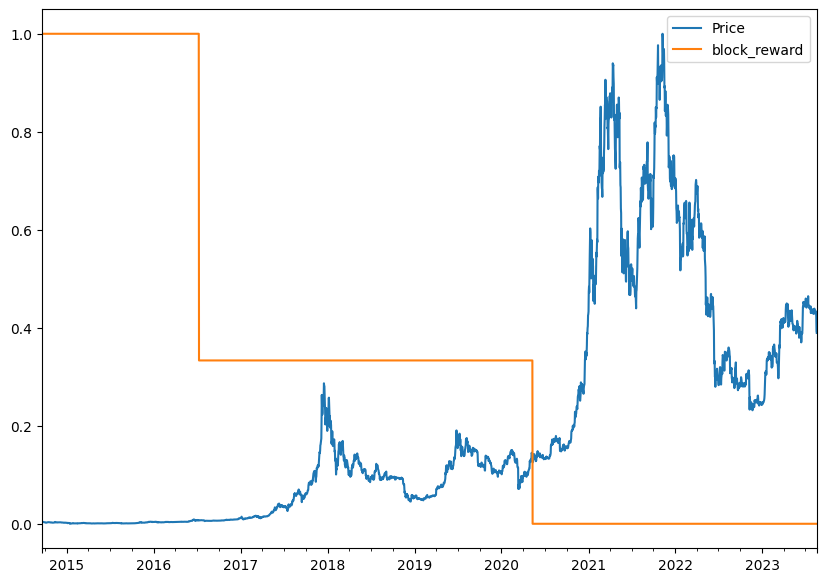

In [ ]:
# Plot the block reward/price over time
# Note: Because of the different scales of our values we'll scale them to be between 0 and 1.
from sklearn.preprocessing import minmax_scale
scaled_price_block_df = pd.DataFrame(minmax_scale(bitcoin_prices_block[["Price", "block_reward"]]), # we need to scale the data first
                                     columns=bitcoin_prices_block.columns,
                                     index=bitcoin_prices_block.index)
scaled_price_block_df.plot(figsize=(10, 7));

When we scale the block reward and the Bitcoin price, we can see the price goes up as the block reward goes down, perhaps this information will be helpful to our model's performance.

## Making a windowed dataset with pandas

Previously, we used some custom made functions to window our **univariate** time series.

The  [`pandas.DataFrame.shift()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.shift.html) method offsets an index by a specified number of periods.

Let's see it in action.

In [ ]:
# Setup dataset hyperparameters
HORIZON = 1
WINDOW_SIZE = 7

In [ ]:
# Make a copy of the Bitcoin historical data with block reward feature
bitcoin_prices_windowed = bitcoin_prices_block.copy()

# Add windowed columns
for i in range(WINDOW_SIZE): # Shift values for each step in WINDOW_SIZE
  bitcoin_prices_windowed[f"Price+{i+1}"] = bitcoin_prices_windowed["Price"].shift(periods=i+1)
bitcoin_prices_windowed.head(10)

,Price,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
2014-09-17 00:00:00+00:00,457.334015,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18 00:00:00+00:00,424.440002,25,457.334015,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19 00:00:00+00:00,394.795990,25,424.440002,457.334015,NaN,NaN,NaN,NaN,NaN
2014-09-20 00:00:00+00:00,408.903992,25,394.795990,424.440002,457.334015,NaN,NaN,NaN,NaN
2014-09-21 00:00:00+00:00,398.821014,25,408.903992,394.795990,424.440002,457.334015,NaN,NaN,NaN
2014-09-22 00:00:00+00:00,402.152008,25,398.821014,408.903992,394.795990,424.440002,457.334015,NaN,NaN
2014-09-23 00:00:00+00:00,435.790985,25,402.152008,398.821014,408.903992,394.795990,424.440002,457.334015,NaN
2014-09-24 00:00:00+00:00,423.204987,25,435.790985,402.152008,398.821014,408.903992,394.795990,424.440002,457.334015
2014-09-25 00:00:00+00:00,411.574005,25,423.204987,435.790985,402.152008,398.821014,408.903992,394.795990,424.440002
2014-09-26 00:00:00+00:00,404.424988,25,411.574005,423.204987,435.790985,402.152008,398.821014,408.903992,394.795990


Now that we've got a windowed dataset, let's separate features (`X`) from labels (`y`).

```
Window for a week (7) to predict a horizon of 1 (multivariate time series)
WINDOW_SIZE & block_reward -> HORIZON

[0, 1, 2, 3, 4, 5, 6, block_reward] -> [7]
[1, 2, 3, 4, 5, 6, 7, block_reward] -> [8]
[2, 3, 4, 5, 6, 7, 8, block_reward] -> [9]
```

Let's remove the `NaN` values using pandas `dropna()`method, this equivalent to starting our windowing function at `sample 0 (the first sample) + WINDOW_SIZE`.

In [ ]:
# Let's create X & y, remove the NaN's and convert to float32 to prevent TensorFlow errors
X = bitcoin_prices_windowed.dropna().drop("Price", axis=1).astype(np.float32)
y = bitcoin_prices_windowed.dropna()["Price"].astype(np.float32)
X.head()

,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
2014-09-24 00:00:00+00:00,25.0,435.790985,402.152008,398.821014,408.903992,394.795990,424.440002,457.334015
2014-09-25 00:00:00+00:00,25.0,423.204987,435.790985,402.152008,398.821014,408.903992,394.795990,424.440002
2014-09-26 00:00:00+00:00,25.0,411.574005,423.204987,435.790985,402.152008,398.821014,408.903992,394.795990
2014-09-27 00:00:00+00:00,25.0,404.424988,411.574005,423.204987,435.790985,402.152008,398.821014,408.903992
2014-09-28 00:00:00+00:00,25.0,399.519989,404.424988,411.574005,423.204987,435.790985,402.152008,398.821014


In [ ]:
# View labels
y.head()

2014-09-24 00:00:00+00:00    423.204987
2014-09-25 00:00:00+00:00    411.574005
2014-09-26 00:00:00+00:00    404.424988
2014-09-27 00:00:00+00:00    399.519989
2014-09-28 00:00:00+00:00    377.181000
Name: Price, dtype: float32

Let's split it into train and test sets using an 80/20 split just as we've done before.

In [ ]:
# Make train and test sets
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(2600, 2600, 651, 651)

## Model 6: Dense model(multivariate time series)

To keep things simple, let's use the `model_1` architecture and use it to train and make predictions on our multivariate time series data.

In [ ]:
tf.random.set_seed(42)

# Make multivariate time series model
model_6 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  # layers.Dense(128, activation="relu"), # adding an extra layer here should lead to beating the naive model
  layers.Dense(HORIZON)
], name="model_6_dense_multivariate")

# Compile
model_6.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Fit
model_6.fit(X_train, y_train,
            epochs=100,
            batch_size=128,
            verbose=0, # only print 1 line per epoch
            validation_data=(X_test, y_test),
            callbacks=[create_model_checkpoint(model_name=model_6.name)])



Time to evaluate our multivariate model.

In [ ]:
# Make sure best model is loaded and evaluate
model_6 = tf.keras.models.load_model("model_experiments/model_6_dense_multivariate")
model_6.evaluate(X_test, y_test)

21/21 [==============================] - 0s 2ms/step - loss: 645.0358


645.0358276367188

In [ ]:
# Make predictions on multivariate data
model_6_preds = tf.squeeze(model_6.predict(X_test))
model_6_preds[:10]

21/21 [==============================] - 0s 1ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([61269.47 , 61490.58 , 62986.84 , 66897.33 , 67288.6  , 65541.1  ,
       65288.566, 64416.547, 64308.48 , 65232.42 ], dtype=float32)>

In [ ]:
# Evaluate preds
model_6_results = evaluate_preds(y_true=y_test,
                                 y_pred=model_6_preds)
model_6_results

{'mae': 645.03577,
 'mse': 1024150.2,
 'rmse': 1012.00305,
 'mape': 2.1017675,
 'mase': 1.0271906}

# Model 7: N-BEATS algorithm



#### **Building and testing an N-BEATS block layer**

Let's start by building an N-BEATS block layer

In [ ]:
# Create NBeatsBlock custom layer
class NBeatsBlock(tf.keras.layers.Layer):
  def __init__(self, # the constructor takes all the hyperparameters for the layer
               input_size: int,
               theta_size: int,
               horizon: int,
               n_neurons: int,
               n_layers: int,
               **kwargs): # the **kwargs argument takes care of all of the arguments for the parent class (input_shape, trainable, name)
    super().__init__(**kwargs)
    self.input_size = input_size
    self.theta_size = theta_size
    self.horizon = horizon
    self.n_neurons = n_neurons
    self.n_layers = n_layers

    # Block contains stack of 4 fully connected layers each has ReLU activation
    self.hidden = [tf.keras.layers.Dense(n_neurons, activation="relu") for _ in range(n_layers)]
    # Output of block is a theta layer with linear activation
    self.theta_layer = tf.keras.layers.Dense(theta_size, activation="linear", name="theta")

  def call(self, inputs): # the call method is what runs when the layer is called
    x = inputs
    for layer in self.hidden: # pass inputs through each hidden layer
      x = layer(x)
    theta = self.theta_layer(x)
    # Output the backcast and forecast from theta
    backcast, forecast = theta[:, :self.input_size], theta[:, -self.horizon:]
    return backcast, forecast

In [ ]:
# Set up dummy NBeatsBlock layer to represent inputs and outputs
dummy_nbeats_block_layer = NBeatsBlock(input_size=WINDOW_SIZE,
                                       theta_size=WINDOW_SIZE+HORIZON, # backcast + forecast
                                       horizon=HORIZON,
                                       n_neurons=128,
                                       n_layers=4)

In [ ]:
# Create dummy inputs (have to be same size as input_size)
dummy_inputs = tf.expand_dims(tf.range(WINDOW_SIZE) + 1, axis=0) # input shape to the model has to reflect Dense layer input requirements (ndim=2)
dummy_inputs

<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[1, 2, 3, 4, 5, 6, 7]], dtype=int32)>

In [ ]:
# Pass dummy inputs to dummy NBeatsBlock layer
backcast, forecast = dummy_nbeats_block_layer(dummy_inputs)
# These are the activation outputs of the theta layer (they'll be random due to no training of the model)
print(f"Backcast: {tf.squeeze(backcast.numpy())}")
print(f"Forecast: {tf.squeeze(forecast.numpy())}")

Backcast: [-0.45330125  1.0589554  -0.57443607 -0.20824534 -0.15116343 -0.30838543
 -0.47064716]
Forecast: 0.4147890508174896


### Preparing data for the N-BEATS algorithm using `tf.data`



In [ ]:
HORIZON = 1 # how far to predict forward
WINDOW_SIZE = 7 # how far to lookback

In [ ]:
# Create NBEATS data inputs (NBEATS works with univariate time series)
bitcoin_prices.head()

,Price
2014-09-17 00:00:00+00:00,457.334015
2014-09-18 00:00:00+00:00,424.440002
2014-09-19 00:00:00+00:00,394.795990
2014-09-20 00:00:00+00:00,408.903992
2014-09-21 00:00:00+00:00,398.821014


In [ ]:
# Add windowed columns
bitcoin_prices_nbeats = bitcoin_prices.copy()
for i in range(WINDOW_SIZE):
  bitcoin_prices_nbeats[f"Price+{i+1}"] = bitcoin_prices_nbeats["Price"].shift(periods=i+1)
bitcoin_prices_nbeats.dropna().head()

,Price,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
2014-09-24 00:00:00+00:00,423.204987,435.790985,402.152008,398.821014,408.903992,394.795990,424.440002,457.334015
2014-09-25 00:00:00+00:00,411.574005,423.204987,435.790985,402.152008,398.821014,408.903992,394.795990,424.440002
2014-09-26 00:00:00+00:00,404.424988,411.574005,423.204987,435.790985,402.152008,398.821014,408.903992,394.795990
2014-09-27 00:00:00+00:00,399.519989,404.424988,411.574005,423.204987,435.790985,402.152008,398.821014,408.903992
2014-09-28 00:00:00+00:00,377.181000,399.519989,404.424988,411.574005,423.204987,435.790985,402.152008,398.821014


In [ ]:
# Make features and labels
X = bitcoin_prices_nbeats.dropna().drop("Price", axis=1)
y = bitcoin_prices_nbeats.dropna()["Price"]

# Make train and test sets
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(2600, 2600, 651, 651)

Train and test sets ready to go!

Now let's convert them into TensorFlow `tf.data.Dataset`'s to ensure they run as fast as possible whilst training.

In [ ]:
# 1. Turn train and test arrays into tensor Datasets
train_features_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset = tf.data.Dataset.from_tensor_slices(y_train)

test_features_dataset = tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset = tf.data.Dataset.from_tensor_slices(y_test)

# 2. Combine features & labels
train_dataset = tf.data.Dataset.zip((train_features_dataset, train_labels_dataset))
test_dataset = tf.data.Dataset.zip((test_features_dataset, test_labels_dataset))

# 3. Batch and prefetch for optimal performance
BATCH_SIZE = 1024 # taken from Appendix D in N-BEATS paper
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset, test_dataset

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>)

Data prepared! Notice the input shape for the features `(None, 7)`, the `None` leaves space for the batch size where as the `7` represents the `WINDOW_SIZE`.



### **Setting up hyperparameters for N-BEATS algorithm**



In [ ]:
# Values from N-BEATS paper Figure 1 and Table 18/Appendix D
N_EPOCHS = 5000 # called "Iterations" in Table 18
N_NEURONS = 512 # called "Width" in Table 18
N_LAYERS = 4
N_STACKS = 30

INPUT_SIZE = WINDOW_SIZE * HORIZON # called "Lookback" in Table 18
THETA_SIZE = INPUT_SIZE + HORIZON

INPUT_SIZE, THETA_SIZE

(7, 8)

### Getting ready for residual connections



In [ ]:
# Make tensors
tensor_1 = tf.range(10) + 10
tensor_2 = tf.range(10)

# Subtract
subtracted = layers.subtract([tensor_1, tensor_2])

# Add
added = layers.add([tensor_1, tensor_2])

print(f"Input tensors: {tensor_1.numpy()} & {tensor_2.numpy()}")
print(f"Subtracted: {subtracted.numpy()}")
print(f"Added: {added.numpy()}")

Input tensors: [10 11 12 13 14 15 16 17 18 19] & [0 1 2 3 4 5 6 7 8 9]
Subtracted: [10 10 10 10 10 10 10 10 10 10]
Added: [10 12 14 16 18 20 22 24 26 28]


### Building, compiling and fitting the N-BEATS algorithm

 Now ready for building and training the N-BEATS algorithm.

We'll do so by going through the following:

1. Setup an instance of the N-BEATS block layer using `NBeatsBlock` (this'll be the initial block used for the network, the rest will be created as part of stacks)
2. Create an input layer for the N-BEATS stack (we'll be using the [Keras Functional API](https://www.tensorflow.org/guide/keras/functional) for this)
3. Make the initial backcast and forecasts for the model with the layer created in (1)
4. Use a for loop to create stacks of block layers
5. Use the NBeatsBlock class within the for loop created in (4) to create blocks which return backcasts and block-level forecasts
6. Create the double residual stacking using subtract and add layers
7. Put the model inputs and outputs together using [`tf.keras.Model()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model)
8. Compile the model with MAE loss (the paper uses multiple losses but we'll use MAE to keep it inline with our other models) and Adam optimizer with default settings as per section 5.2 of [N-BEATS paper](https://arxiv.org/pdf/1905.10437.pdf))
9. Fit the N-BEATS model for 5000 epochs and since it's fitting for so many epochs, we'll use a couple of callbacks:
  * [`tf.keras.callbacks.EarlyStopping()`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) - stop the model from training if it doesn't improve validation loss for 200 epochs and restore the best performing weights using `restore_best_weights=True` (this'll prevent the model from training for loooongggggg period of time without improvement)
  * [`tf.keras.callbacks.ReduceLROnPlateau()`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ReduceLROnPlateau) - if the model's validation loss doesn't improve for 100 epochs, reduce the learning rate by 10x to try and help it make incremental improvements (the smaller the learning rate, the smaller updates a model tries to make)



In [ ]:
 %%time

tf.random.set_seed(42)

# 1. Setup N-BEATS Block layer
nbeats_block_layer = NBeatsBlock(input_size=INPUT_SIZE,
                                 theta_size=THETA_SIZE,
                                 horizon=HORIZON,
                                 n_neurons=N_NEURONS,
                                 n_layers=N_LAYERS,
                                 name="InitialBlock")

# 2. Create input to stacks
stack_input = layers.Input(shape=(INPUT_SIZE), name="stack_input")

# 3. Create initial backcast and forecast input (backwards predictions are referred to as residuals in the paper)
backcast, forecast = nbeats_block_layer(stack_input)
# Add in subtraction residual link, thank you to: https://github.com/mrdbourke/tensorflow-deep-learning/discussions/174
residuals = layers.subtract([stack_input, backcast], name=f"subtract_00")

# 4. Create stacks of blocks
for i, _ in enumerate(range(N_STACKS-1)): # first stack is already creted in (3)

  # 5. Use the NBeatsBlock to calculate the backcast as well as block forecast
  backcast, block_forecast = NBeatsBlock(
      input_size=INPUT_SIZE,
      theta_size=THETA_SIZE,
      horizon=HORIZON,
      n_neurons=N_NEURONS,
      n_layers=N_LAYERS,
      name=f"NBeatsBlock_{i}"
  )(residuals) # pass it in residuals (the backcast)

  # 6. Create the double residual stacking
  residuals = layers.subtract([residuals, backcast], name=f"subtract_{i}")
  forecast = layers.add([forecast, block_forecast], name=f"add_{i}")

# 7. Put the stack model together
model_7 = tf.keras.Model(inputs=stack_input,
                         outputs=forecast,
                         name="model_7_N-BEATS")

# 8. Compile with MAE loss and Adam optimizer
model_7.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["mae", "mse"])

# 9. Fit the model with EarlyStopping and ReduceLROnPlateau callbacks
model_7.fit(train_dataset,
            epochs=N_EPOCHS,
            validation_data=test_dataset,
            verbose=0, # prevent large amounts of training outputs
            # callbacks=[create_model_checkpoint(model_name=stack_model.name)] # saving model every epoch consumes far too much time
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=200, restore_best_weights=True),
                      tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=100, verbose=1)])


Epoch 166: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 266: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
CPU times: user 1min 45s, sys: 1.96 s, total: 1min 47s
Wall time: 1min 59s


In [ ]:
# Evaluate N-BEATS model on the test dataset
model_7.evaluate(test_dataset)

1/1 [==============================] - 0s 25ms/step - loss: 657.8463 - mae: 657.8463 - mse: 1066246.1250


[657.8463134765625, 657.8463134765625, 1066246.125]

In [ ]:
# Make predictions with N-BEATS model
model_7_preds = make_preds(model_7, test_dataset)
model_7_preds[:10]

1/1 [==============================] - 1s 1s/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([61308.637, 61354.707, 62674.746, 66246.695, 66911.84 , 65766.66 ,
       65261.77 , 64084.184, 64368.215, 65264.285], dtype=float32)>

In [ ]:
# Evaluate N-BEATS model predictions
model_7_results = evaluate_preds(y_true=y_test,
                                 y_pred=model_7_preds)
model_7_results

{'mae': 657.8463,
 'mse': 1066246.1,
 'rmse': 1032.5919,
 'mape': 2.1423573,
 'mase': 1.0475907}

even with all of those special layers and hand-crafted network, it looks like the N-BEATS model doesn't perform as well as model_1 or the original naive forecast.

This goes to show the power of smaller networks as well as the fact not all larger models are better suited for a certain type of data.

### Plotting the N-BEATS architecture we've created

we can using [`tensorflow.keras.utils.plot_model()`](https://www.tensorflow.org/api_docs/python/tf/keras/utils/plot_model).


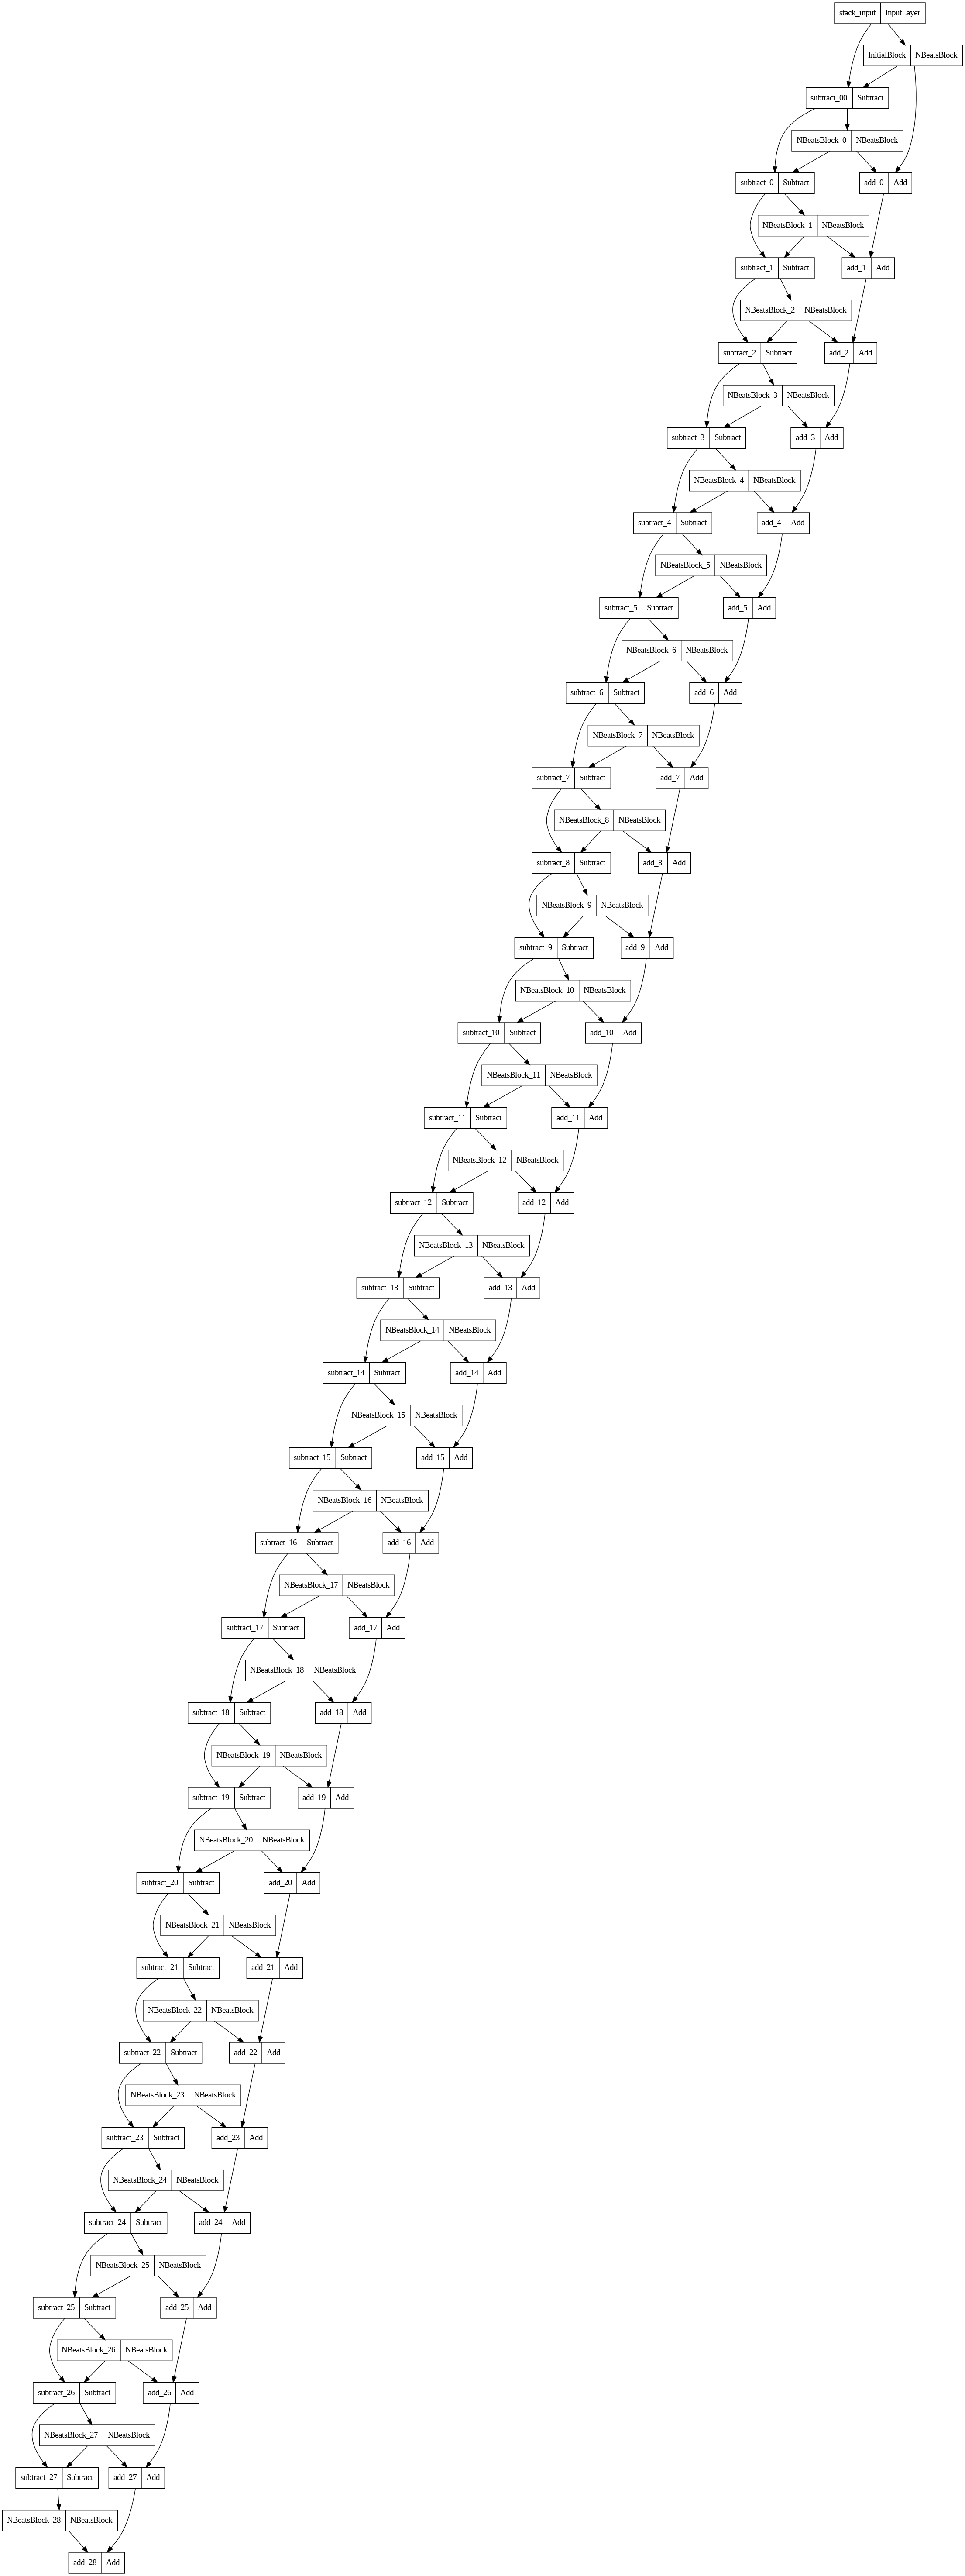

In [ ]:
# Plot the N-BEATS model and inspect the architecture
from tensorflow.keras.utils import plot_model
plot_model(model_7)

In [ ]:
model_7.save(model_7.name)



> 📖 **Resource:** If you would like to save and load the N-BEATS model or any other custom or subclassed layer/model configuration, you should overwrite the `get_config()` and optionally `from_config()` methods. See the [TensorFlow Custom Objects documentation](https://www.tensorflow.org/guide/keras/save_and_serialize#custom_objects) for more.

## Model 8: Creating an ensemble (stacking different models together)

After all that effort, the N-BEATS algorithm's performance was underwhelming.



Our next experiment is creating an [**ensemble** of models](https://en.wikipedia.org/wiki/Ensemble_learning).

An **ensemble** involves training and combining multiple different models on the same problem. Ensemble models are often the types of models you'll see winning data science competitions on websites like Kaggle.


Essentially, we'll be creating a suite of different models all attempting to model the same data and hopefully the combined predictive power of each model is better than a single model on its own.

Let's find out!

We'll start by creating a function to produce a list of different models trained with different loss functions. Each layer in the ensemble models will be initialized with a random normal [(Gaussian) distribution](https://en.wikipedia.org/wiki/Normal_distribution) using [He normal initialization](https://www.tensorflow.org/api_docs/python/tf/keras/initializers/HeNormal), this'll help estimating the prediction intervals later on.



### Constructing and fitting an ensemble of models (using different loss functions)

In [ ]:
def get_ensemble_models(horizon=HORIZON,
                        train_data=train_dataset,
                        test_data=test_dataset,
                        num_iter=10,
                        num_epochs=100,
                        loss_fns=["mae", "mse", "mape"]):
  """
  Returns a list of num_iter models each trained on MAE, MSE and MAPE loss.

  For example, if num_iter=10, a list of 30 trained models will be returned:
  10 * len(["mae", "mse", "mape"]).
  """
  # Make empty list for trained ensemble models
  ensemble_models = []

  # Create num_iter number of models per loss function
  for i in range(num_iter):
    # Build and fit a new model with a different loss function
    for loss_function in loss_fns:
      print(f"Optimizing model by reducing: {loss_function} for {num_epochs} epochs, model number: {i}")

      # Construct a simple model (similar to model_1)
      model = tf.keras.Sequential([
        # Initialize layers with normal (Gaussian) distribution so we can use the models for prediction
        # interval estimation later: https://www.tensorflow.org/api_docs/python/tf/keras/initializers/HeNormal
        layers.Dense(128, kernel_initializer="he_normal", activation="relu"),
        layers.Dense(128, kernel_initializer="he_normal", activation="relu"),
        layers.Dense(HORIZON)
      ])

      # Compile simple model with current loss function
      model.compile(loss=loss_function,
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=["mae", "mse"])

      # Fit model
      model.fit(train_data,
                epochs=num_epochs,
                verbose=0,
                validation_data=test_data,
                # Add callbacks to prevent training from going/stalling for too long
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                            patience=200,
                                                            restore_best_weights=True),
                           tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                                patience=100,
                                                                verbose=1)])

      # Append fitted model to list of ensemble models
      ensemble_models.append(model)

  return ensemble_models # return list of trained models

Ensemble model creator function created!

Let's try it out by running `num_iter=5` runs for 1000 epochs. This will result in 15 total models (5 for each different loss function).

>  **Note:** With ensembles, you'll generally find more total models means better performance. However, this comes with the tradeoff of having to train more models (longer training time) and make predictions with more models (longer prediction time).



In [ ]:
%%time
# Get list of trained ensemble models
ensemble_models = get_ensemble_models(num_iter=5,
                                      num_epochs=1000)

Optimizing model by reducing: mae for 1000 epochs, model number: 0
Optimizing model by reducing: mse for 1000 epochs, model number: 0

Epoch 413: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 513: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing model by reducing: mape for 1000 epochs, model number: 0

Epoch 203: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 314: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.

Epoch 414: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
Optimizing model by reducing: mae for 1000 epochs, model number: 1

Epoch 452: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 552: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing model by reducing: mse for 1000 epochs, model number: 1

Epoch 301: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 401: ReduceLROnPl

### Making predictions with an ensemble model

In [ ]:
# Create a function which uses a list of trained models to make and return a list of predictions
def make_ensemble_preds(ensemble_models, data):
  ensemble_preds = []
  for model in ensemble_models:
    preds = model.predict(data) # make predictions with current ensemble model
    ensemble_preds.append(preds)
  return tf.constant(tf.squeeze(ensemble_preds))

In [ ]:
# Create a list of ensemble predictions
ensemble_preds = make_ensemble_preds(ensemble_models=ensemble_models,
                                     data=test_dataset)
ensemble_preds

1/1 [==============================] - 0s 37ms/step


1/1 [==============================] - 0s 44ms/step


1/1 [==============================] - 0s 40ms/step


<tf.Tensor: shape=(15, 651), dtype=float32, numpy=
array([[60916.805, 61303.188, 63047.03 , ..., 29108.629, 28549.904,
        26669.932],
       [60867.04 , 61251.297, 63166.023, ..., 29046.363, 28641.04 ,
        26553.852],
       [60991.297, 61585.37 , 63203.453, ..., 29125.533, 28638.969,
        26711.367],
       ...,
       [61176.727, 61500.484, 63522.6  , ..., 29265.854, 28841.086,
        26822.95 ],
       [61152.863, 61411.184, 62939.14 , ..., 29180.51 , 28660.53 ,
        26795.887],
       [61493.81 , 61907.707, 63998.12 , ..., 29465.848, 29027.607,
        27272.104]], dtype=float32)>

Now we've got a set of ensemble predictions, we can evaluate them against the ground truth values.

However, since we've trained 15 models, there's going to be 15 sets of predictions. Rather than comparing every set of predictions to the ground truth, let's take the median (you could also take the mean too but [the median is usually more robust than the mean](https://www.johndcook.com/blog/2009/03/06/student-t-distribution-mean-median/)).

In [ ]:
# Evaluate ensemble model(s) predictions
ensemble_results = evaluate_preds(y_true=y_test,
                                  y_pred=np.median(ensemble_preds, axis=0)) # take the median across all ensemble predictions
ensemble_results

{'mae': 631.4861,
 'mse': 987751.1,
 'rmse': 993.8567,
 'mape': 2.0590181,
 'mase': 1.0056132}

Looks like the ensemble model is the best performing model on the MAE metric so far.

### Plotting the prediction intervals (uncertainty estimates) of our ensemble

Right now all of our model's (prior to the ensemble model) are predicting single points.

Meaning, given a set of `WINDOW_SIZE=7` values, the model will predict `HORIZION=1`.



One way of getting the 95% condfidnece prediction intervals for a deep learning model is the bootstrap method:
1. Take the predictions from a number of randomly initialized models (we've got this thanks to our ensemble model)
2. Measure the standard deviation of the predictions
3. Multiply standard deviation by [1.96](https://en.wikipedia.org/wiki/1.96) (assuming the distribution is Gaussian, 95% of observations fall within 1.96 standard deviations of the mean, this is why we initialized our neural networks with a normal distribution)
4. To get the prediction interval upper and lower bounds, add and subtract the value obtained in (3) to the mean/median of the predictions made in (1)


In [ ]:
# Find upper and lower bounds of ensemble predictions
def get_upper_lower(preds): # 1. Take the predictions of multiple randomly initialized deep learning neural networks

  # 2. Measure the standard deviation of the predictions
  std = tf.math.reduce_std(preds, axis=0)

  # 3. Multiply the standard deviation by 1.96
  interval = 1.96 * std # https://en.wikipedia.org/wiki/1.96

  # 4. Get the prediction interval upper and lower bounds
  preds_mean = tf.reduce_mean(preds, axis=0)
  lower, upper = preds_mean - interval, preds_mean + interval
  return lower, upper

# Get the upper and lower bounds of the 95%
lower, upper = get_upper_lower(preds=ensemble_preds)

Now we've got the upper and lower bounds for the the 95% prediction interval, let's plot them against our ensemble model's predictions.

To do so, we can use our plotting function as well as the [`matplotlib.pyplot.fill_between()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html) method to shade in the space between the upper and lower bounds.

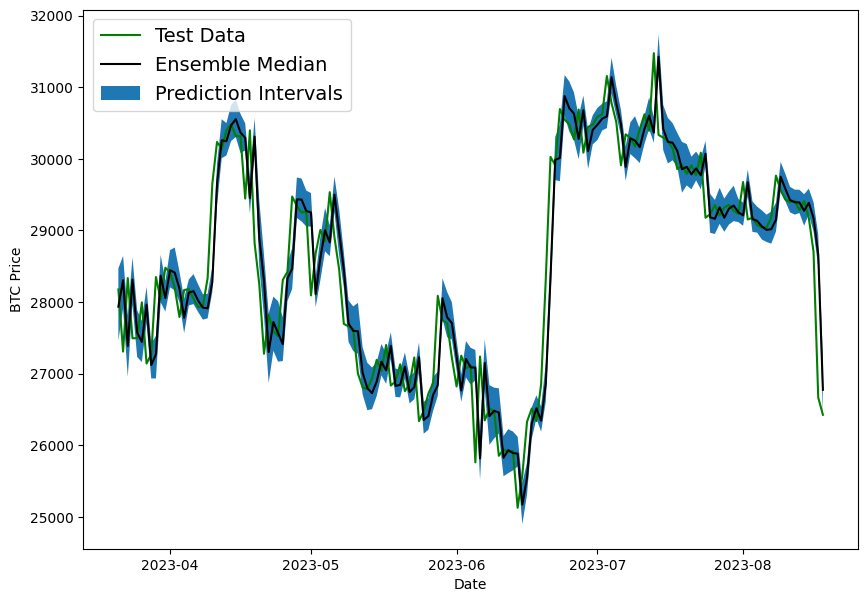

In [ ]:
# Get the median values of our ensemble preds
ensemble_median = np.median(ensemble_preds, axis=0)

# Plot the median of our ensemble preds along with the prediction intervals (where the predictions fall between)
offset=500
plt.figure(figsize=(10, 7))
plt.plot(X_test.index[offset:], y_test[offset:], "g", label="Test Data")
plt.plot(X_test.index[offset:], ensemble_median[offset:], "k-", label="Ensemble Median")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.fill_between(X_test.index[offset:],
                 (lower)[offset:],
                 (upper)[offset:], label="Prediction Intervals")
plt.legend(loc="upper left", fontsize=14);

We've just plotted:
* The test data (the ground truth Bitcoin prices)
* The median of the ensemble predictions
* The 95% prediction intervals (assuming the data is Gaussian/normal, the model is saying that 95% of the time, predicted value should fall between this range)

What can you tell about the ensemble model from the plot above?

It looks like the ensemble predictions are lagging slightly behind the actual data.

And the prediction intervals are fairly low throughout.

The combination of lagging predictions as well as low prediction intervals indicates that our ensemble model may be **overfitting** the data, meaning it's basically replicating what a naïve model would do and just predicting the previous timestep value for the next value.

This would explain why previous attempts to beat the naïve forecast have been futile.

We can test this hypothesis of overfitting by creating a model to make predictions into the future and seeing what they look like.




## Model 9: Train a model on the full historical data to make predictions into future



To make predictions into the future, we'll train a model on the full dataset and then get to make predictions to some future horizon.


Previously, we split our data into training and test sets to evaluate how our model did on pseudo-future data (the test set).

But since the goal of a forecasting model is to predict values into the actual-future, we won't be using a test set.


Let's get some data ready.

In [ ]:
bitcoin_prices_windowed.head()

,Price,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
2014-09-17 00:00:00+00:00,457.334015,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18 00:00:00+00:00,424.440002,25,457.334015,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19 00:00:00+00:00,394.795990,25,424.440002,457.334015,NaN,NaN,NaN,NaN,NaN
2014-09-20 00:00:00+00:00,408.903992,25,394.795990,424.440002,457.334015,NaN,NaN,NaN,NaN
2014-09-21 00:00:00+00:00,398.821014,25,408.903992,394.795990,424.440002,457.334015,NaN,NaN,NaN


In [ ]:
# Train model on entire data to make prediction for the next day
X_all = bitcoin_prices_windowed.drop(["Price", "block_reward"], axis=1).dropna().to_numpy() # only want prices, our future model can be a univariate model
y_all = bitcoin_prices_windowed.dropna()["Price"].to_numpy()

Windows and labels ready! Let's turn them into performance optimized TensorFlow Datasets by:
1. Turning `X_all` and `y_all` into tensor Datasets using [`tf.data.Dataset.from_tensor_slices()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_tensor_slices)
2. Combining the features and labels into a Dataset tuple using [`tf.data.Dataset.zip()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#zip)
3. Batch and prefetch the data using [`tf.data.Dataset.batch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#batch) and [`tf.data.Dataset.prefetch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch) respectively

In [ ]:
# 1. Turn X and y into tensor Datasets
features_dataset_all = tf.data.Dataset.from_tensor_slices(X_all)
labels_dataset_all = tf.data.Dataset.from_tensor_slices(y_all)

# 2. Combine features & labels
dataset_all = tf.data.Dataset.zip((features_dataset_all, labels_dataset_all))

# 3. Batch and prefetch for optimal performance
BATCH_SIZE = 1024 # taken from Appendix D in N-BEATS paper
dataset_all = dataset_all.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

dataset_all

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

Now let's create a model similar to `model_1` except with an extra layer, we'll also fit it to the entire dataset for 100 epochs.

In [ ]:
tf.random.set_seed(42)

# Create model (nice and simple, just to test)
model_9 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON)
])

# Compile
model_9.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam())

# Fit model on all of the data to make future forecasts
model_9.fit(dataset_all,
            epochs=100,
            verbose=0) # don't print out anything, we've seen this all before

### Make predictions on the future



As we have seen so far, our machine learning models have performed quite poorly at predicting the price of Bitcoin (time series forecasting in open systems is typically a game of luck), often worse than the naive forecast.

et's start by defining a variable `INTO_FUTURE` which decides how many timesteps we'd like to predict into the future.

In [ ]:
# How many timesteps to predict into the future?
INTO_FUTURE = 14 # since our Bitcoin data is daily, this is for 14 days

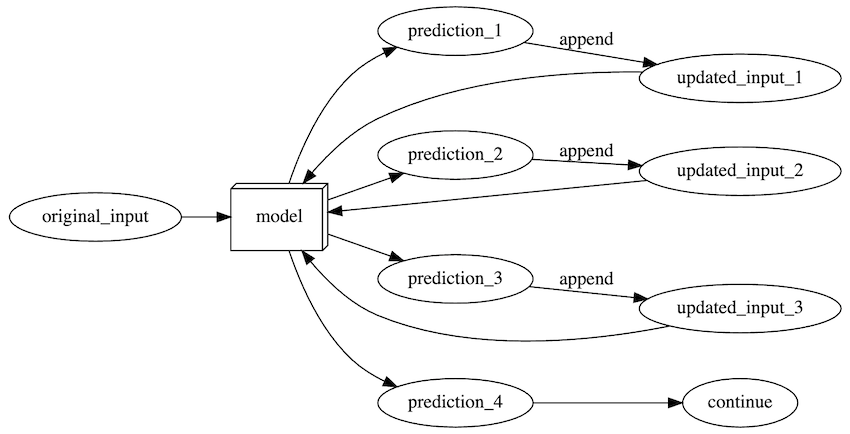


let's create a function which returns `INTO_FUTURE` forecasted values using a trained model.

To do so, we'll build the following steps:
1. Function which takes as input:
  * a list of values (the Bitcoin historical data)
  * a trained model (such as `model_9`)
  * a window into the future to predict (our `INTO_FUTURE` variable)
  * the window size a model was trained on (`WINDOW_SIZE`) - the model can only predict on the same kind of data it was trained on
2. Creates an empty list for future forecasts (this will be returned at the end of the function) and extracts the last `WINDOW_SIZE` values from the input values (predictions will start from the last `WINDOW_SIZE` values of the training data)
3. Loop `INTO_FUTURE` times making a prediction on `WINDOW_SIZE` datasets which update to remove the first the value and append the latest prediction
  * Eventually future predictions will be made using the model's own previous predictions as input

In [ ]:
# 1. Create function to make predictions into the future
def make_future_forecast(values, model, into_future, window_size=WINDOW_SIZE) -> list:
  """
  Makes future forecasts into_future steps after values ends.

  Returns future forecasts as list of floats.
  """
  # 2. Make an empty list for future forecasts/prepare data to forecast on
  future_forecast = []
  last_window = values[-WINDOW_SIZE:] # only want preds from the last window (this will get updated)

  # 3. Make INTO_FUTURE number of predictions, altering the data which gets predicted on each time
  for _ in range(into_future):

    # Predict on last window then append it again, again, again (model starts to make forecasts on its own forecasts)
    future_pred = model.predict(tf.expand_dims(last_window, axis=0))
    print(f"Predicting on: \n {last_window} -> Prediction: {tf.squeeze(future_pred).numpy()}\n")

    # Append predictions to future_forecast
    future_forecast.append(tf.squeeze(future_pred).numpy())
    # print(future_forecast)

    # Update last window with new pred and get WINDOW_SIZE most recent preds (model was trained on WINDOW_SIZE windows)
    last_window = np.append(last_window, future_pred)[-WINDOW_SIZE:]

  return future_forecast

In [ ]:
# Make forecasts into future of the price of Bitcoin
# Note: if you're reading this at a later date, you may already be in the future, so the forecasts
# we're making may not actually be forecasts, if that's the case, readjust the training data.
future_forecast = make_future_forecast(values=y_all,
                                       model=model_9,
                                       into_future=INTO_FUTURE,
                                       window_size=WINDOW_SIZE)

1/1 [==============================] - 0s 52ms/step
Predicting on: 
 [29415.96484375 29282.9140625  29408.44335938 29170.34765625
 28701.77929688 26664.55078125 26424.28320312] -> Prediction: 29617.33984375

1/1 [==============================] - 0s 20ms/step
Predicting on: 
 [29282.9140625  29408.44335938 29170.34765625 28701.77929688
 26664.55078125 26424.28320312 29617.33984375] -> Prediction: 29362.37890625

1/1 [==============================] - 0s 20ms/step
Predicting on: 
 [29408.44335938 29170.34765625 28701.77929688 26664.55078125
 26424.28320312 29617.33984375 29362.37890625] -> Prediction: 29042.1328125

1/1 [==============================] - 0s 17ms/step
Predicting on: 
 [29170.34765625 28701.77929688 26664.55078125 26424.28320312
 29617.33984375 29362.37890625 29042.1328125 ] -> Prediction: 28588.564453125

1/1 [==============================] - 0s 26ms/step
Predicting on: 
 [28701.77929688 26664.55078125 26424.28320312 29617.33984375
 29362.37890625 29042.1328125  28588.5

In [ ]:
future_forecast[:10]

[29617.34,
 29362.379,
 29042.133,
 28588.564,
 27735.871,
 27297.535,
 28621.863,
 29510.182,
 29084.676,
 28677.137]

### Plot future forecasts

To plot our model's future forecasts against the historical data of Bitcoin, we're going to need a series of future dates (future dates from the final date of where our dataset ends).

 Let's create a function to return a date range from some specified start date to a specified number of days into the future (`INTO_FUTURE`).

To do so, we'll use a combination of NumPy's [`datetime64` datatype](https://numpy.org/doc/stable/reference/arrays.datetime.html) (our Bitcoin dates are already in this datatype) as well as NumPy's `timedelta64` method which helps to create date ranges.

In [ ]:
def get_future_dates(start_date, into_future, offset=1):
  """
  Returns array of datetime values from ranging from start_date to start_date+horizon.

  start_date: date to start range (np.datetime64)
  into_future: number of days to add onto start date for range (int)
  offset: number of days to offset start_date by (default 1)
  """
  start_date = start_date + np.timedelta64(offset, "D") # specify start date, "D" stands for day
  end_date = start_date + np.timedelta64(into_future, "D") # specify end date
  return np.arange(start_date, end_date, dtype="datetime64[D]") # return a date range between start date and end date

The start date of our forecasted dates will be the last date of our dataset.

In [ ]:
# Last timestep of timesteps (currently in np.datetime64 format)
last_timestep = bitcoin_prices.index[-1]
last_timestep

Timestamp('2023-08-18 00:00:00+0000', tz='UTC')

In [ ]:
# Convert "last_timestep" to a NumPy datetime64 type
last_timestep = np.datetime64(last_timestep)

# Get next two weeks of timesteps
next_time_steps = get_future_dates(start_date=last_timestep, into_future=INTO_FUTURE)
next_time_steps


<ipython-input-135-ea0b12ed2186>:2: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  last_timestep = np.datetime64(last_timestep)


array(['2023-08-19', '2023-08-20', '2023-08-21', '2023-08-22',
       '2023-08-23', '2023-08-24', '2023-08-25', '2023-08-26',
       '2023-08-27', '2023-08-28', '2023-08-29', '2023-08-30',
       '2023-08-31', '2023-09-01'], dtype='datetime64[D]')

In [ ]:
# Insert last timestep/final price so the graph doesn't look messed
next_time_steps = np.insert(next_time_steps, 0, last_timestep)
future_forecast = np.insert(future_forecast, 0, bitcoin_prices['Price'][-1])
next_time_steps, future_forecast

(array(['2023-08-18', '2023-08-19', '2023-08-20', '2023-08-21',
        '2023-08-22', '2023-08-23', '2023-08-24', '2023-08-25',
        '2023-08-26', '2023-08-27', '2023-08-28', '2023-08-29',
        '2023-08-30', '2023-08-31', '2023-09-01'], dtype='datetime64[D]'),
 array([26424.283, 29617.34 , 29362.379, 29042.133, 28588.564, 27735.871,
        27297.535, 28621.863, 29510.182, 29084.676, 28677.137, 28217.398,
        27957.648, 28481.637, 29247.174], dtype=float32))

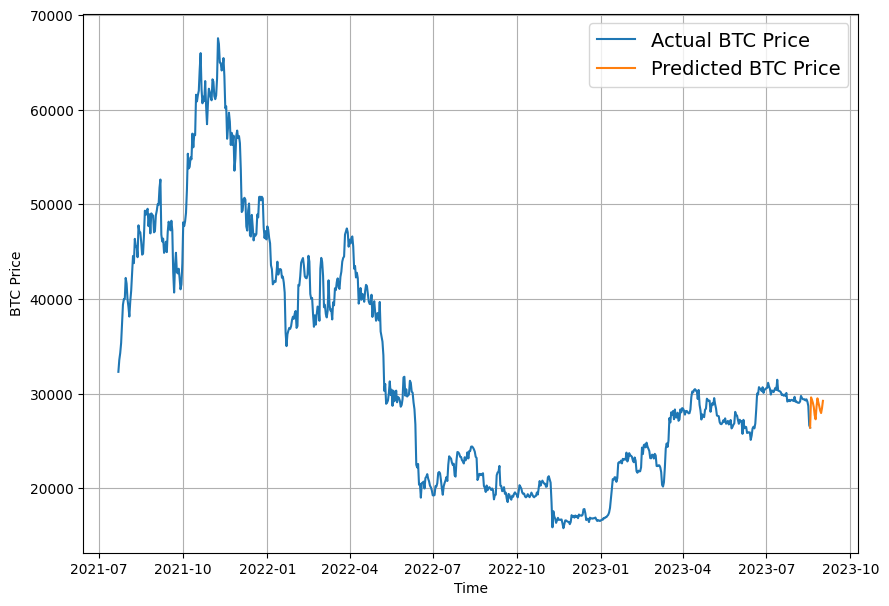

In [ ]:
next_time_steps = next_time_steps[-16:]
future_forecast = future_forecast[-16:]
# Plot future price predictions of Bitcoin
plt.figure(figsize=(10, 7))
plot_time_series(bitcoin_prices.index, bitcoin_prices['Price'], start=2500, format="-", label="Actual BTC Price")
plot_time_series(next_time_steps, future_forecast, format="-", label="Predicted BTC Price")

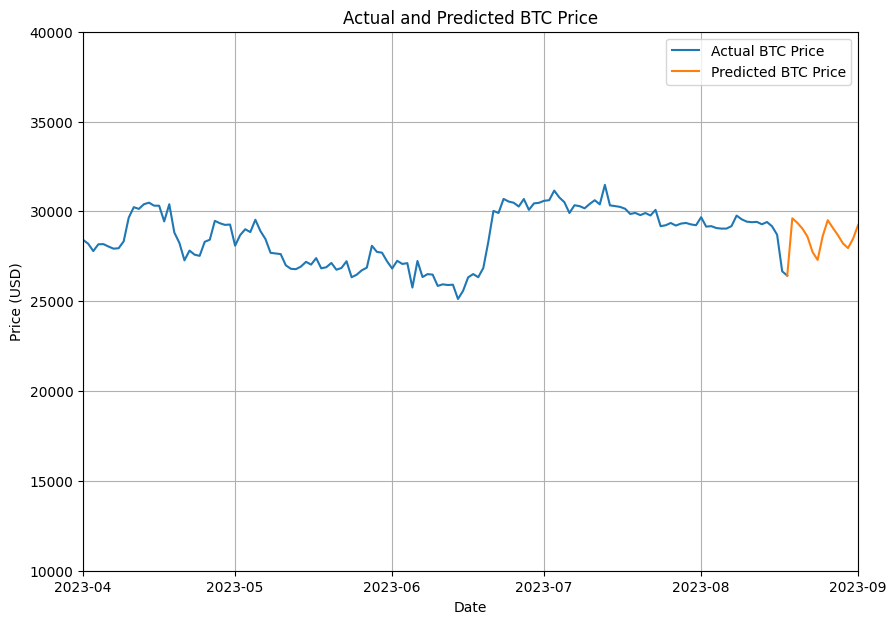

In [ ]:
# Plot future price predictions of Bitcoin
plt.figure(figsize=(10, 7))

# Plot actual BTC price
plt.plot(bitcoin_prices.index, bitcoin_prices['Price'], label="Actual BTC Price")

# Plot predicted BTC price
plt.plot(next_time_steps, future_forecast, label="Predicted BTC Price")

plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Actual and Predicted BTC Price")
plt.legend()
# Zoom in on a specific region (customize the axis limits as needed)
plt.xlim(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-09-01'))
plt.ylim(10000, 40000)

plt.grid(True)
plt.show()

## **Compare Models**


In [ ]:
# Compare different model results (w = window, h = horizon, e.g. w=7 means a window size of 7)
model_results = pd.DataFrame({"naive_model": naive_results,
                              "model_1_dense_w7_h1": model_1_results,
                              "model_2_dense_w30_h1": model_2_results,
                              "model_3_dense_w30_h7": model_3_results,
                              "model_4_CONV1D": model_4_results,
                              "model_5_LSTM": model_5_results,
                              "model_6_multivariate": model_6_results,
                              "model_8_NBEATs": model_7_results,
                              "model_9_ensemble": ensemble_results }).T
model_results.head(9)

,mae,mse,rmse,mape,mase
naive_model,627.613770,9.759490e+05,987.901306,2.047601,0.999447
model_1_dense_w7_h1,640.129272,1.014066e+06,1007.008362,2.087862,1.019377
model_2_dense_w30_h1,719.720947,1.168330e+06,1080.893066,2.363199,1.161949
model_3_dense_w30_h7,1377.685547,4.357377e+06,1589.498535,4.568017,2.216939
model_4_CONV1D,666.322266,1.078347e+06,1038.434814,2.167948,1.061088
model_5_LSTM,675.568970,1.079116e+06,1038.805176,2.200140,1.075813
model_6_multivariate,645.035767,1.024150e+06,1012.003052,2.101768,1.027191
model_8_NBEATs,657.846313,1.066246e+06,1032.591919,2.142357,1.047591
model_9_ensemble,631.486084,9.877511e+05,993.856689,2.059018,1.005613


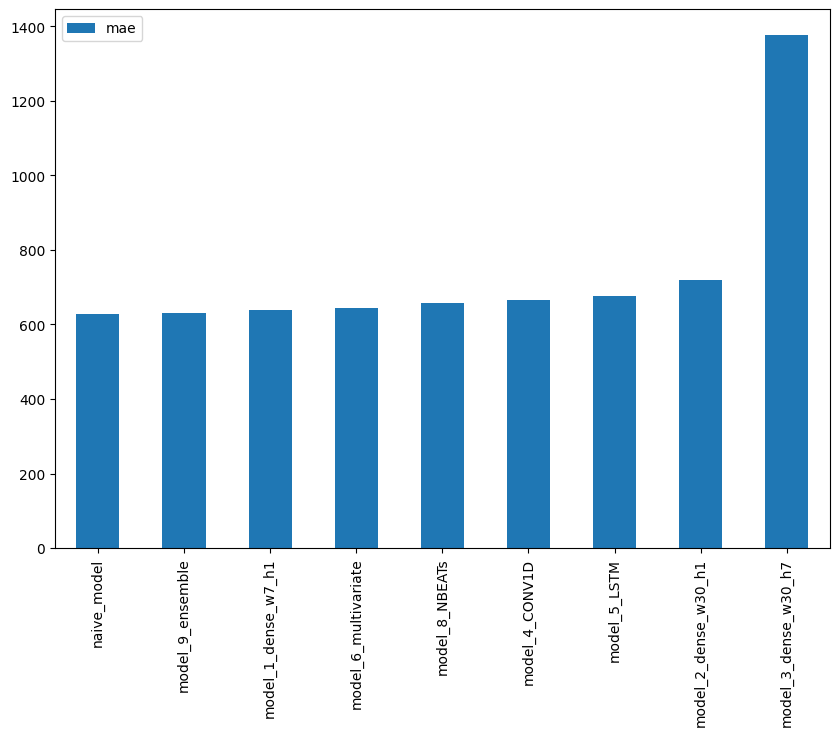

In [ ]:
# Sort model results by MAE and plot them
model_results[["mae"]].sort_values(by="mae").plot(figsize=(10, 7), kind="bar");